In [1]:
# basic plotting imports
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import h5py

import numpy as np
import pandas as pd

from neurodsp import spectral
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.preprocessing import OneHotEncoder
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectFromModel
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import Ridge

from spikeparam.patch.fit import Spike
from spikeparam.patch.fit import SpikeGroup

from tqdm.notebook import tqdm

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(rc={'figure.figsize':(12,9)})
sns.set_style('whitegrid')
sns.set_style("whitegrid", {'axes.grid' : False})

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


#### Data source

These data are the [PVC-6 data from CRCNS](https://crcns.org/data-sets/vc/pvc-6/about_pvc-6). From their summary:

>The data sets consist of whole cell current clamp slice electrophysiology recordings made from single neurons from coronal sections of the visual cortex of adult male mice. The experiments were performed in the presence of blockers of fast synaptic transmission with the goal of understanding the diversity of intrinsic neuronal excitability between cell classes. These experiments represent preliminary datasets being used to refine methods working towards producing slice electrophysiology data at scale.

These data are ideal for several reasons. First, and most critical for us, is that they're sampled at 200,000 Hz! So if we want to parameterize individual action potentials, for a 1ms AP we'll have 200 data points. This is much more approachable than the 20-40 datapoints that have been limiting us on the other datsets.

Second, these are intracellular patch clamp recordings, so they're not susceptible to our concern that extracellular AP shapes are affected by the position of the electrode relative to the neuron, which is not necessaily stable over time (meaning that any observed AP shape differences could theoretically be driven by movement rather than physiology).

Finally, these neurons were driven by 1/f pink noise, which we like a lot. The variability of the 1/f exponent over time will allow us to link stimulus parameters to any variation in AP shape parameters.

In [2]:
# open and load the data

fs = 200000 # sampling rate
one_ms = int(fs / 1000)

total_sweeps = 66

# 153098_04_02_data has 0 through 66 sweeps
# 151145_04_Data  has 0 through 91 sweeps
filename = '/Users/blancamartin/Downloads/151145.04_Data.h5' # filename

# open file
f = h5py.File(filename, 'r')

# list(f.keys())

# qc_data = f['qcSweep_Key']
# qc_data[0, :, :]

In [3]:
# helper functions

# load sweeps
def load_sweep(sweep_number):
    # load sweep
    dset = f['Sweep_' + str(sweep_number)]

    # create array of time indices
    convert_to_ms = (fs / 1000)
    times = np.arange(0, np.shape(dset)[0]) / convert_to_ms # in ms instead of sec

    return dset, times

# get the power spectrum of the stimulus
def get_stim_spectrum(dset, fs, nperseg, all_data=True):
    
    if all_data == True:
        stim_data = dset[:, 0]
        fxx, pxx = spectral.compute_spectrum(stim_data, fs, method='welch',
                    window='hann', nperseg=nperseg)
    
    if all_data == False:
        fxx, pxx = spectral.compute_spectrum(dset, fs, method='welch',
                window='hann', nperseg=nperseg)
        
    return fxx, pxx

# plot the ephys data
def plot_ephys_data(dset, times, index_start, index_end):
    plot_range = (index_start, index_end)
    plt.plot(times[plot_range[0]:plot_range[1]],
        dset[plot_range[0]:plot_range[1], 1], '.')

# plot the stimulus
def plot_stim_data(dset, times, index_start, index_end):
    plot_range = (index_start, index_end)
    plt.plot(times[plot_range[0]:plot_range[1]],
        dset[plot_range[0]:plot_range[1], 0], '.')

# plot the stimulus spectrum
def plot_stim_spectrum(fxx, pxx, xlim, ylim):
    plt.loglog(fxx, pxx)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power (V^2/Hz)')
    plt.xlim(xlim)
    plt.ylim(ylim)

# find the spike times
def find_spike_times(data, thresh_mv, thresh_ms):
    # thresh_mv is the voltage threshold that needs to be crossed
    # thresh_ms is how many ms each peak needs to be from the next

    peaks = find_peaks(data, height=thresh_mv, distance=thresh_ms)
    idx_spikes = peaks[0] # spike indices
    amp_spikes = peaks[1]['peak_heights'] # spike amplitudes

    return idx_spikes, amp_spikes

# define exponential function
def exp_func(times, exp_amp, exp_lambda, exp_timeshift, exp_const):
    return exp_amp * np.exp(-exp_lambda * (times - exp_timeshift)) + exp_const

# fit exponential data
def fit_exp_nonlinear(times, data, initial_guesses, bounds):
    popt, _ = curve_fit(exp_func, times, data, p0=initial_guesses, bounds=bounds,  maxfev=10000)
    exp_amp, exp_lambda, exp_timeshift, exp_const = popt
    return exp_amp, exp_lambda, exp_timeshift, exp_const

#### Constant current

Some of the sweeps are driven by a constant current, as can be seen below. For now we'll ignore these, but in theory, depending on the stimulus parameters, these could be used to measure any AP shape parameter adaptation over time, as well as a control to compare against 1/f pink noise stimulation.

In [6]:
sweep_number = 3
index_start = 403900
index_end = 406000

dset, times = load_sweep(sweep_number)


#### Pink noise (1/f) stimulation

Many of the sweeps are drive by pink noise, and we can leverage the variability in this stimulus to examine the link between variations in the stimulus and AP shape parameters.

In [8]:
sweep_number = 14
index_start = 0
index_end = int(10e10)

dset, times = load_sweep(sweep_number)



#### Pink noise stimulus spectrum

You can see below that the stimulus is only 1/f in the range of ~[10, 200], so for future 1/f paramterization, we'll fit a linear regression to the loglog spectrum on that range, if the time windows are sufficient. - the analysis here was running specparam on the data not the stimulus :0 

### Do all the pink noise info gathering here

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_95964/4261919025.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(np.arange(np.size(stim_data)), stim_data)


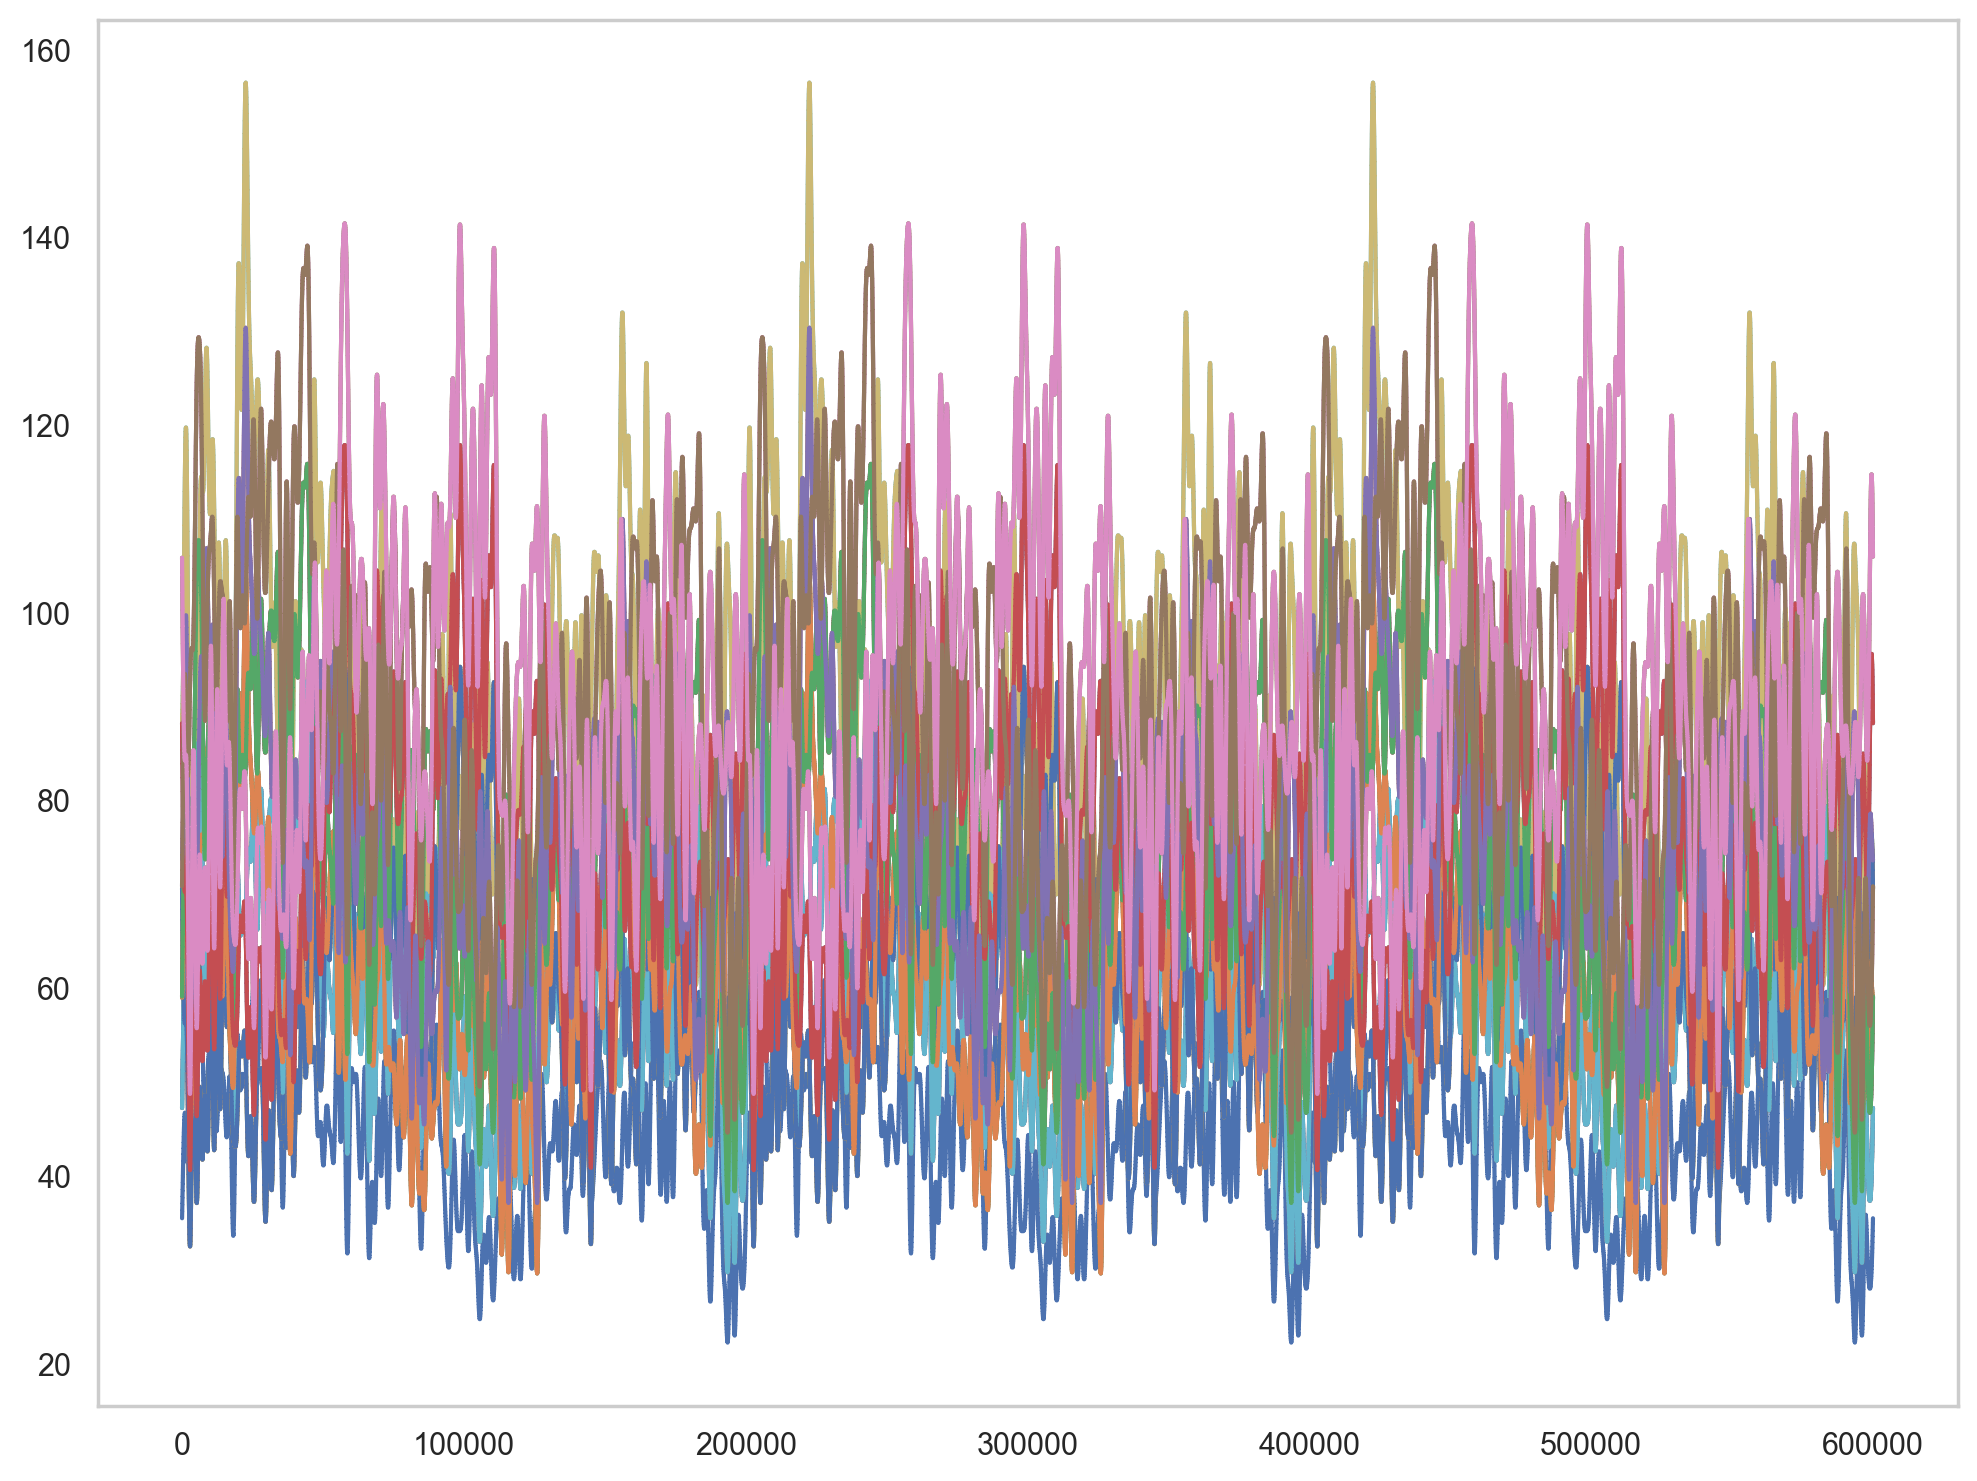

In [9]:
#generate dict with info of pink noise variations
all_pink_noise = {}
pink_type_num = 0
#pink_stim_dict = {}
pink_types = []



# 0 through 66 sweeps
for i_sweeps in range(66):


    #load data
    dset, times = load_sweep(i_sweeps)

    stim_data = dset[:, 0] # current injection
    

    # set the first 25 ms to zero to get rid of mini-pulse at beginning
    stim_data[0:5000] = 0
    stim_data = stim_data[stim_data!=0]
    
 

    if np.size(stim_data) > 2:
        # a pearson correlation between current and time is
            # nan for constant, near 1.0 for ramp, and low for pink noise
        r, _ = pearsonr(np.arange(np.size(stim_data)), stim_data)
        

        # check stim type
        if (np.isnan(r)):
            stim_type = 'constant'
            pink_type = 'constant'
        elif (~np.isnan(r) & (r>0.95)):
            stim_type = 'ramp'
            pink_type = 'ramp'
        elif (~np.isnan(r) & (r<0.95)):
            stim_type = 'pink'
            plt.plot(stim_data)
          
    else:
        stim_type = 'none'
        pink_type = 'none'


    if stim_type == 'pink':
        
        #get specific variation of pink noise 
        if r  not in all_pink_noise:
            pink_type_num = pink_type_num + 1
            pink_type = 'PinkNoise'+str(pink_type_num)
            all_pink_noise[r] = pink_type
            #get power spec for that pink noise type 
            fxx, pxx = get_stim_spectrum(stim_data, fs, nperseg=fs/4, all_data = False)
            xlim = (10e-2, 10e5)
            ylim = (10e-10, 10e-1)
            #plot_stim_spectrum(fxx, pxx, xlim, ylim)
            #plt.axvline(x=10)
            #plt.axvline(x=200)
            #plt.title(pink_type)
            #plt.show()


        else:
            pink_type = all_pink_noise[r]
            
    pink_types.append(pink_type)
        
        
            
   

       


### Print example pink noise for schematic figure

In [10]:
pink_types

['ramp',
 'ramp',
 'ramp',
 'constant',
 'constant',
 'constant',
 'constant',
 'constant',
 'constant',
 'constant',
 'constant',
 'constant',
 'constant',
 'constant',
 'none',
 'constant',
 'constant',
 'constant',
 'PinkNoise1',
 'PinkNoise2',
 'PinkNoise3',
 'PinkNoise4',
 'constant',
 'PinkNoise5',
 'PinkNoise6',
 'PinkNoise7',
 'constant',
 'PinkNoise8',
 'PinkNoise9',
 'PinkNoise10',
 'constant',
 'constant',
 'constant',
 'constant',
 'constant',
 'constant',
 'constant',
 'constant',
 'constant',
 'PinkNoise2',
 'PinkNoise3',
 'PinkNoise4',
 'constant',
 'PinkNoise5',
 'PinkNoise6',
 'PinkNoise7',
 'constant',
 'PinkNoise8',
 'PinkNoise9',
 'PinkNoise10',
 'constant',
 'constant',
 'constant',
 'constant',
 'constant',
 'constant',
 'PinkNoise2',
 'PinkNoise3',
 'PinkNoise4',
 'constant',
 'PinkNoise5',
 'PinkNoise6',
 'PinkNoise7',
 'constant',
 'PinkNoise8',
 'PinkNoise9']

#### Process the data!

The pink noise sweeps all begin with a brief (sub-threshold, always?) stimulus, and then the pink noise stimulus that evokes APs. I use a simple peak-finding approach to find all APs, and then extract time windows around those APs for parameterization of both the APs and the stimulus.

In order to find the inflection point where the AP "starts", we take the difference (~derivative) of the intracellular data around the spike, and find the point where that derivative rises above the noise. This differenced time series is smoothed using simple lowess smoothing, to make things easier.

One cool thing to note here is how similar to an extracelluar AP this derivative of the intracellular AP looks! This probably isn't a coincidence, and has been remarked upon for a very long time. It's worth considering in our future analyses.

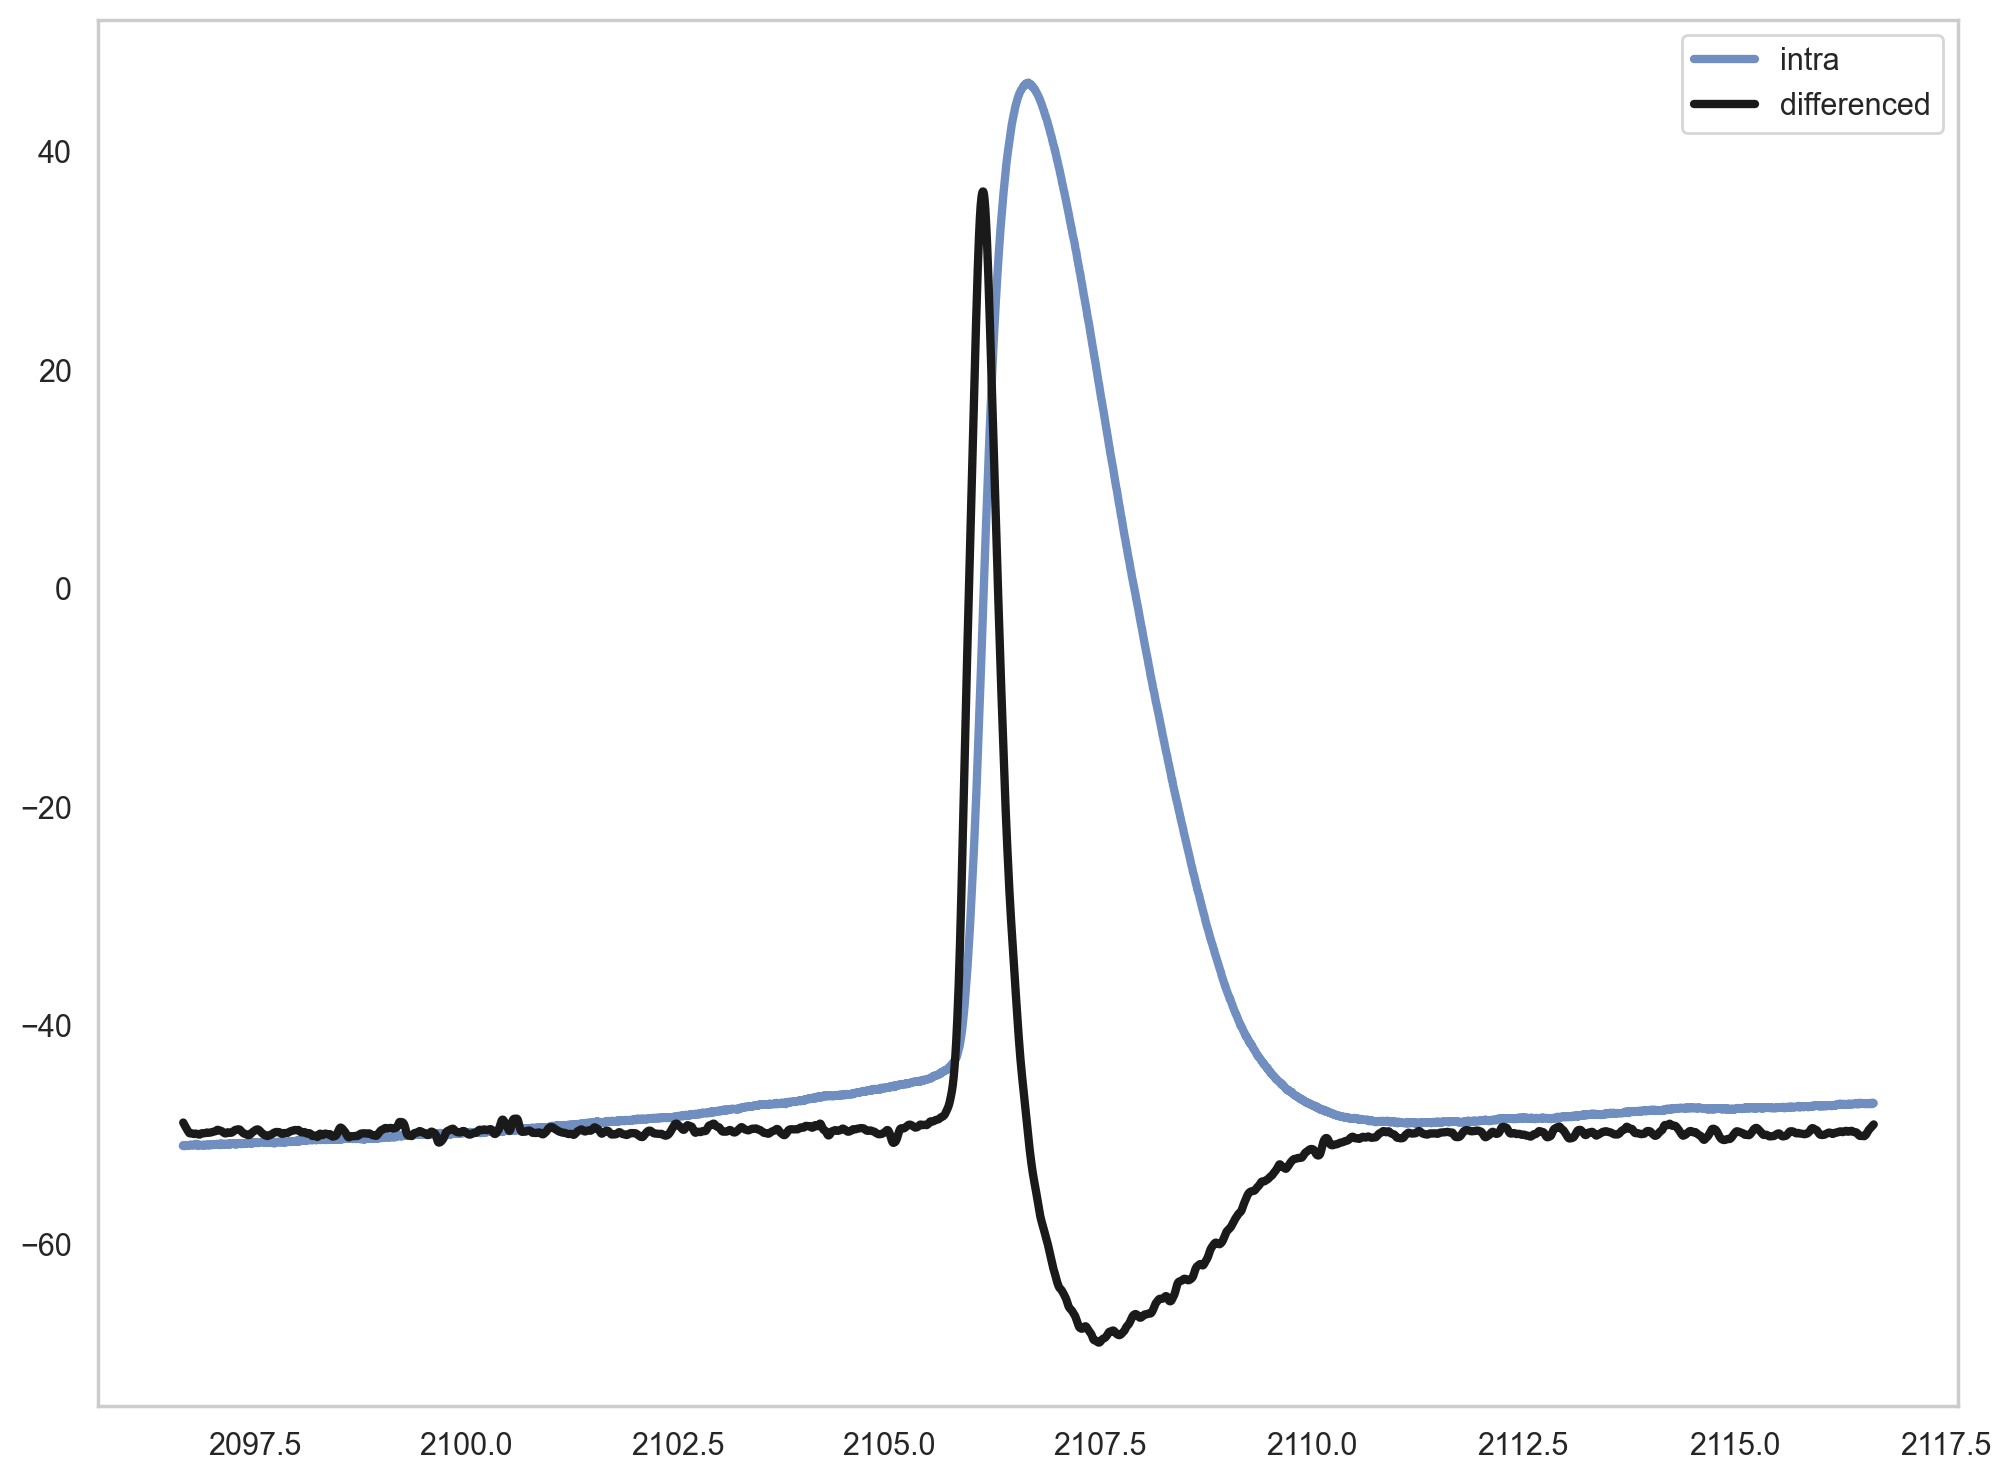

In [11]:
# Plot single spike, and its derivative
i_sweeps = 28
dset, times = load_sweep(i_sweeps)

stim = dset[:, 0] # current injection
data = dset[:, 1] # ephys data

#########################
# find spikes
thresh_mv = -10
thresh_ms = one_ms * 1 # 1 ms

idx_spikes, amp_spikes = find_spike_times(data, thresh_mv, thresh_ms)

#########################
i_spikes = 0
    
# get windows around spikes
# create window indices
window_length = (10, 10) # in ms
window_pre = int(one_ms * window_length[0])
window_post = int(one_ms * window_length[1])

# get window
window_spike_pre = (idx_spikes[i_spikes]-window_pre)
window_spike_post = (idx_spikes[i_spikes]+window_post)

# get window for times as well
windowed_times = times[(idx_spikes[i_spikes]-window_pre):
                    (idx_spikes[i_spikes]+window_post)]

# get data window
windowed_data = data[window_spike_pre:window_spike_post]

# difference of data, and smooth it
d_windowed_data = np.diff(windowed_data)
smoothed_data = sm.nonparametric.lowess(d_windowed_data, windowed_times[1:], frac=0.008)

# smoothed data
d_smoothed_times = smoothed_data[:, 0]
d_smoothed_data = smoothed_data[:, 1]

plt.plot(windowed_times, windowed_data, 'b', alpha = 0.8, linewidth = 3., label='intra')
plt.plot(d_smoothed_times, (d_smoothed_data*80)-50, 'k', linewidth = 3., label='differenced')
plt.legend()
plt.show()

### Parameterize complete dataset 

In [12]:
all_data = []
for i_sweeps in range(66):

    #load data
    dset, times = load_sweep(i_sweeps)

    
    data = dset[:, 1] # ephys data
    all_data.append(data)

In [13]:

df_sweep = []
df_stim_type = []
df_spike_number = []
df_voltage_ramp = []
df_inflection_time = []
df_inflection_mv = []
df_peak_amplitude = []
df_peak_sharpness = []
df_decay_lambda = []
df_decay_const = []
# df_spike_width = []
df_stim_exp = []
df_stim_mean = []
df_stim_std = []
df_pinktype = []

all_contant_spks = []
all_ramp_spks = []
all_pink_spks = []

# 0 through 66 sweeps
for i_sweeps in range(66):

    #load data
    dset, times = load_sweep(i_sweeps)

    stim = dset[:, 0] # current injection
    data = dset[:, 1] # ephys data

    #########################
    # find spikes
    thresh_mv = -10
    thresh_ms = one_ms * 1 # 1 ms

    idx_spikes, amp_spikes = find_spike_times(data, thresh_mv, thresh_ms)

    #########################
    # loop across spikes
    if np.size(idx_spikes) > 0:

        #########################
        # check if sweep stim is constant, ramp, or pink

        stim_data = dset[:, 0]

        # set the first 25 ms to zero to get rid of mini-pulse at beginning
        stim_data[0:5000] = 0
        stim_data = stim_data[stim_data!=0]

        if np.size(stim_data) > 2:
            # a pearson correlation between current and time is
                # nan for constant, near 1.0 for ramp, and low for pink noise
            r, _ = pearsonr(np.arange(np.size(stim_data)), stim_data)

            # check stim type
            if (np.isnan(r)):
                stim_type = 'constant'
            elif (~np.isnan(r) & (r>0.95)):
                stim_type = 'ramp'
            elif (~np.isnan(r) & (r<0.95)):
                stim_type = 'pink'
        else:
            stim_type = 'none'

        #########################
        # paramterize each spike
        for i_spikes in range(np.size(idx_spikes)):
            # get windows around spikes
            # create window indices
            window_length = (10, 10) # in ms
            window_pre = int(one_ms * window_length[0])
            window_post = int(one_ms * window_length[1])

            # get window
            window_spike_pre = (idx_spikes[i_spikes]-window_pre)
            window_spike_post = (idx_spikes[i_spikes]+window_post)

            # get window for times as well
            windowed_times = times[(idx_spikes[i_spikes]-window_pre):
                                (idx_spikes[i_spikes]+window_post)]

            # get data window
            windowed_data = data[window_spike_pre:window_spike_post]

            # difference of data, and smooth it
            d_windowed_data = np.diff(windowed_data)
            smoothed_data = sm.nonparametric.lowess(d_windowed_data, windowed_times[1:], frac=0.008)

            # smoothed data
            d_smoothed_times = smoothed_data[:, 0]
            d_smoothed_data = smoothed_data[:, 1]

            if stim_type == 'constant':
                all_contant_spks.append(d_smoothed_data )
            elif stim_type == 'ramp':
                all_ramp_spks.append(d_smoothed_data )
            elif stim_type == 'pink':
                all_pink_spks.append(d_smoothed_data )
                 


            #########################
            # inflection_time
            thresh_zscore = 40 # zscore threshold for inflection point
                                # REALLY high, since it's so low noise

            # get mean and std of first ms of data
            noise_window = d_smoothed_data[0:one_ms] 
            noise_mean = np.mean(noise_window)
            noise_std = np.std(noise_window)

            # zscore spike relative to window above
            z_data = (d_smoothed_data-noise_mean) / noise_std

            # find the peak of the zscored data
            idx_z_peak, _ = find_spike_times(z_data, thresh_zscore, thresh_ms)

            # find the peak of the real data
            idx_spike_peak, _ = find_spike_times(windowed_data, thresh_mv, thresh_ms)

            # find inflection voltage and time relative to spike peak
            inflection_time = np.abs(z_data[0:idx_z_peak[0]]-thresh_zscore)
            idx_inflection = np.argmin(inflection_time)

            # get the voltage ramp slope for the 0.5 ms before inflection point
            idx_ramp_start = idx_inflection - int(0.5 * one_ms) # 0.5 ms before
            ramp_times = windowed_times[idx_ramp_start:idx_inflection]

            voltage_ramp, _ = np.polyfit(ramp_times, windowed_data[idx_ramp_start:idx_inflection], 1)

            inflection_time = idx_spike_peak - idx_inflection
            inflection_time = inflection_time[0] / one_ms

            inflection_mv = windowed_data[idx_inflection]


            #########################
            # peak voltage
            idx_spike_peak, amp_spike_peak = find_spike_times(windowed_data, thresh_mv, thresh_ms)
            mv_peak = amp_spike_peak[0]


            #########################
            # peak sharpness
                # this is just Scott's simple oscillation sharpness approach
            sharpness_peak = ((windowed_data[idx_spike_peak[0]]-windowed_data[idx_spike_peak[0]-5]) + 
            (windowed_data[idx_spike_peak[0]]-windowed_data[idx_spike_peak[0]+5])) / 2


            #########################
            # voltage decay rate and voltage floor
            decay_curve_shift = one_ms/2 # the ap peak is curved, so shift to the right to get a cleaner decay
            decay_curve_floor_time = one_ms*5 # decide when to call it the floor
            idx_spike_peak, amp_peak = find_spike_times(windowed_data, thresh_mv, thresh_ms)
            exp_window = idx_spike_peak[0]+int(decay_curve_shift) # shift to the right
            exp_window_end = exp_window+int(decay_curve_floor_time) # when to end the curve
            exp_data = windowed_data[exp_window:exp_window_end]
            exp_times = windowed_times[exp_window:exp_window_end]

            # initial guesses, derived from physiological estimating
            initial_guesses = np.array([50, 1, windowed_times[exp_window], -60], dtype=np.float64)
            bounds = ([0, 0, 0, -100], [1000, 3, 10e9, 50]) # set some reasonable bounds

            # fit the dang thing
            exp_amp, exp_lambda, exp_timeshift, exp_const = \
                fit_exp_nonlinear(exp_times, exp_data, initial_guesses, bounds)

            # # check the fit
            # fitted_model = exp_func(exp_times, exp_amp, exp_lambda, exp_timeshift, exp_const)

            # # plot it!
            # plt.plot(exp_times, exp_data, 'k')
            # plt.plot(exp_times, fitted_model, 'b')
            # plt.show()


            if stim_type == 'pink':
                #########################
                # quantify stimulus parameters

                # create window indices
                window_length = (10, 10) # in ms
                window_pre = int(one_ms * window_length[0])
                window_post = int(one_ms * window_length[1])
                
                # get the 5 ms before the inflection point
                inflection_pre_window = int(idx_inflection - (one_ms * 5))

                # get window
                window_spike_pre = (idx_spikes[i_spikes]-window_pre)
                window_spike_post = (idx_spikes[i_spikes]+window_post)

                windowed_stim = stim[window_spike_pre:window_spike_post]
                windowed_stim = windowed_stim[inflection_pre_window:idx_inflection]

                # get slope of spectrum (exponent)
                fxx, pxx = spectral.compute_spectrum(windowed_stim, fs, method='welch',
                                window='hann', nperseg=np.size(windowed_stim))

                # get rid of zero Hz
                fxx = fxx[1:]
                pxx = pxx[1:]

                stim_exp, _ = np.polyfit(np.log10(fxx), np.log10(pxx), 1)
                stim_exp = -stim_exp # change from slope to exponent

                # stim mean and std
                stim_mean = np.mean(windowed_stim)
                stim_std = np.std(windowed_stim)
            
            else: # not pink noise, so set stim params to nan
                stim_exp = np.nan
                stim_mean = np.nan
                stim_std = np.nan


            #########################
            # collect all the relevant features
            df_sweep.append(i_sweeps)
            df_stim_type.append(stim_type)
            df_spike_number.append(i_spikes)
            df_voltage_ramp.append(voltage_ramp)
            df_inflection_time.append(inflection_time)
            df_inflection_mv.append(inflection_mv)
            df_peak_amplitude.append(mv_peak)
            df_peak_sharpness.append(sharpness_peak)
            df_decay_lambda.append(exp_lambda)
            df_decay_const.append(exp_const)
            # df_spike_width.append(spike_width)
            df_stim_exp.append(stim_exp)
            df_stim_mean.append(stim_mean)
            df_stim_std.append(stim_std)
            df_pinktype.append(pink_types[i_sweeps])


/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_95964/819899920.py:53: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = pearsonr(np.arange(np.size(stim_data)), stim_data)


In [14]:
#try collapsing the all data array to 1d (concatenate all sweeps)
all_data_flat =  [n for one_dim in all_data for n in one_dim]

In [15]:

#recreate parameterization using the Spike class
#Run spikeparam on real EAPs 
sp = Spike(thresh_amp=-10, window_length=(5., 5.), smooth_frac=.008, pre_inflection_ms = 0.5)


sp.fit(all_data_flat, fs, n_jobs=-1, progress=tqdm)

Spike:   0%|          | 0/377 [00:00<?, ?it/s]

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.



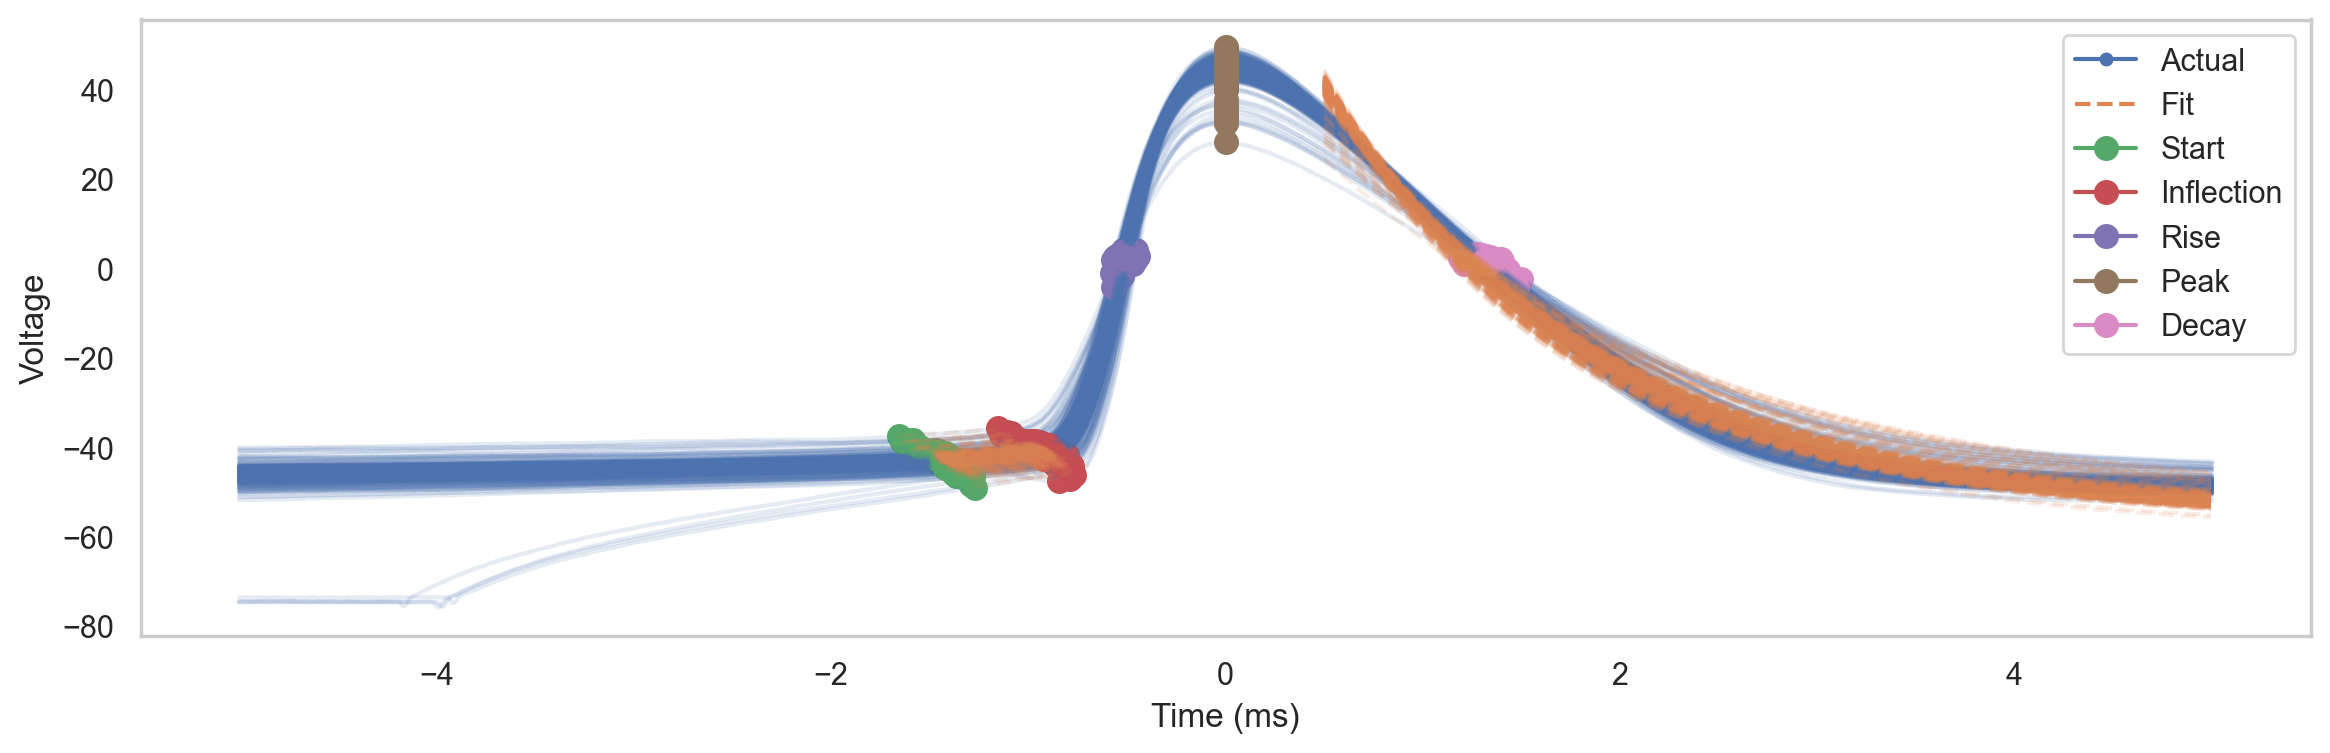

In [16]:
sp.plot(show_points=True)

In [17]:
""""
for i in range(len(all_data)):
    #recreate parameterization using the Spike class
    #Run spikeparam on real EAPs 
    sp = Spike(thresh_amp=-10, window_length=(10., 10.), smooth_frac=.008, pre_inflection_ms = 0.5)
    
    
    sp.fit(all_data[i], fs, n_jobs=-1, progress=tqdm)"""

'"\nfor i in range(len(all_data)):\n    #recreate parameterization using the Spike class\n    #Run spikeparam on real EAPs \n    sp = Spike(thresh_amp=-10, window_length=(10., 10.), smooth_frac=.008, pre_inflection_ms = 0.5)\n    \n    \n    sp.fit(all_data[i], fs, n_jobs=-1, progress=tqdm)'

In [18]:
#sp.df_features

In [19]:
# create df
    # stim_type = 'constant', 'ramp', 'pink'
df = pd.DataFrame({'sweep': df_sweep, 'stim_type': df_stim_type, 'spike_num': df_spike_number,
                    'voltage_ramp': df_voltage_ramp, 'inflection_time': df_inflection_time,
                    'inflection_amp': df_inflection_mv, 'peak_amp': df_peak_amplitude,
                    'peak_sharp': df_peak_sharpness, 'decay_exp': df_decay_lambda,
                    'decay_const': df_decay_const, 'stim_exp': df_stim_exp, 'stim_mean': df_stim_mean,
                    'stim_std': df_stim_std,'pink_type':df_pinktype },
        columns=['sweep', 'stim_type', 'spike_num', 'voltage_ramp', 'inflection_time', 'inflection_amp',
                'peak_amp', 'peak_sharp', 'decay_exp', 'decay_const', 'stim_exp', 'stim_mean', 'stim_std', 'pink_type'])


In [20]:
df

,sweep,stim_type,spike_num,voltage_ramp,inflection_time,inflection_amp,peak_amp,peak_sharp,decay_exp,decay_const,stim_exp,stim_mean,stim_std,pink_type
0,2,ramp,0,5.205671,0.860,-39.281251,47.062501,0.093750,0.793694,-55.363803,NaN,NaN,NaN,ramp
1,2,ramp,1,4.914942,0.855,-38.812501,46.625001,0.140625,0.757432,-55.689707,NaN,NaN,NaN,ramp
2,7,constant,0,3.742574,0.795,-45.218751,48.593751,0.078125,0.821547,-56.775265,NaN,NaN,NaN,constant
3,11,constant,0,-0.671055,4.140,-74.125002,47.687501,0.125000,0.809100,-56.447122,NaN,NaN,NaN,constant
4,16,constant,0,4.844060,0.850,-42.656251,47.437501,0.031250,0.838273,-53.285591,NaN,NaN,NaN,constant
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,65,pink,15,5.248125,0.865,-39.656251,43.937501,0.078125,0.747452,-52.695311,0.659722,99.514875,3.355962,PinkNoise9
376,65,pink,16,5.640152,0.850,-38.843751,43.156251,0.031250,0.717525,-53.621177,1.298633,119.563250,2.833350,PinkNoise9
377,65,pink,17,6.491674,0.835,-39.375001,43.812501,0.046875,0.736518,-52.894002,1.386186,122.388375,2.546485,PinkNoise9
378,65,pink,18,5.508551,0.900,-39.062501,43.468751,0.031250,0.719819,-52.651467,0.551817,110.324750,7.318235,PinkNoise9


### plot avg waveform for constant vs ramp vs pink noise 

(1600.0, 2400.0)

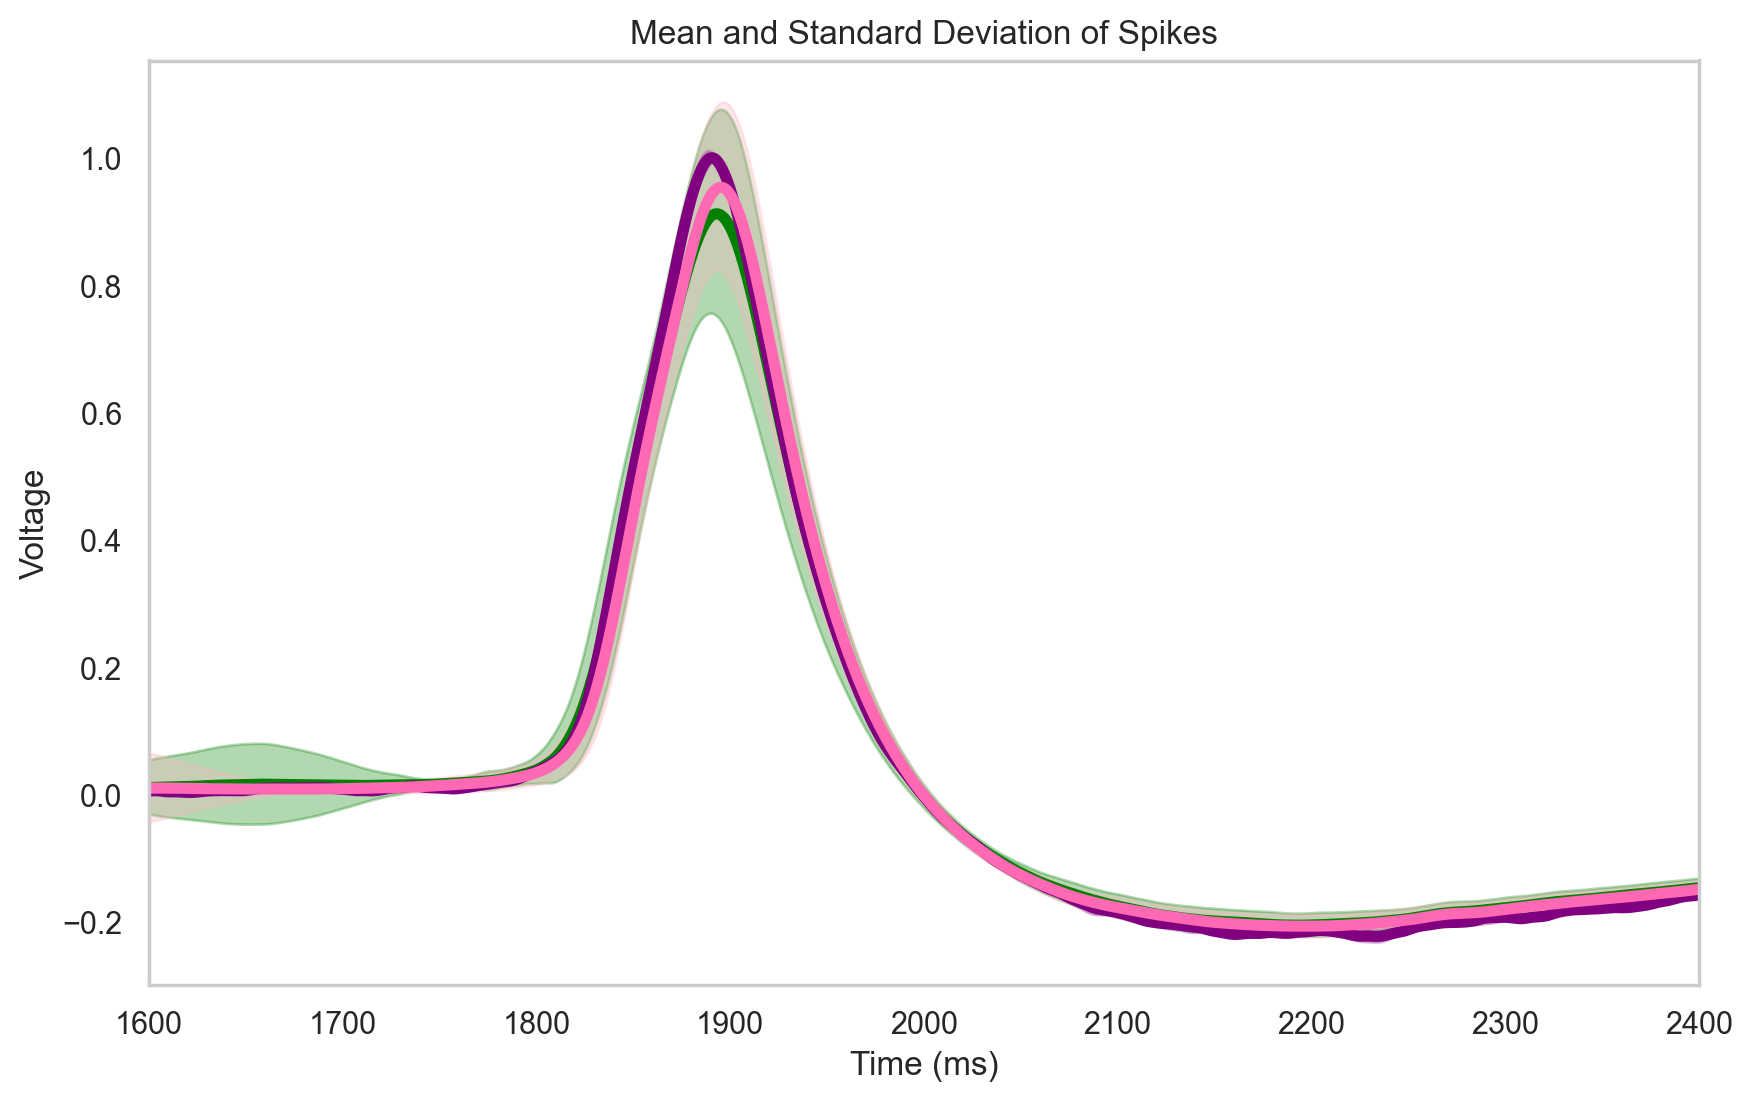

In [21]:
# Calculate mean and standard deviation for each array
mean_constant_spks = np.mean(all_contant_spks, axis=0)
std_constant_spks = np.std(all_contant_spks, axis=0)

mean_ramp_spks = np.mean(all_ramp_spks, axis=0)
std_ramp_spks = np.std(all_ramp_spks, axis=0)

mean_pink_spks = np.mean(all_pink_spks, axis=0)
std_pink_spks = np.std(all_pink_spks, axis=0)

# Plot the mean and standard deviation
plt.figure(figsize=(10, 6))

# Plot for all_constant_spks
plt.plot(mean_constant_spks, label='Mean Constant Spikes', color='green', linewidth=4)
plt.fill_between(range(len(mean_constant_spks)), mean_constant_spks - std_constant_spks, mean_constant_spks + std_constant_spks, color='green', alpha=0.3)

# Plot for all_ramp_spks
plt.plot(mean_ramp_spks, label='Mean Ramp Spikes', color='purple', linewidth=4)
plt.fill_between(range(len(mean_ramp_spks)), mean_ramp_spks - std_ramp_spks, mean_ramp_spks + std_ramp_spks, color='purple', alpha=0.3)

# Plot for all_pink_spks
plt.plot(mean_pink_spks, label='Mean Pink Spikes', color='hotpink', linewidth=4)
plt.fill_between(range(len(mean_pink_spks)), mean_pink_spks - std_pink_spks, mean_pink_spks + std_pink_spks, color='lightpink', alpha=0.3)

# Set plot labels and title
plt.xlabel('Time (ms)')
plt.ylabel('Voltage')
plt.title('Mean and Standard Deviation of Spikes')
#plt.legend()
plt.xlim(1600,2400)



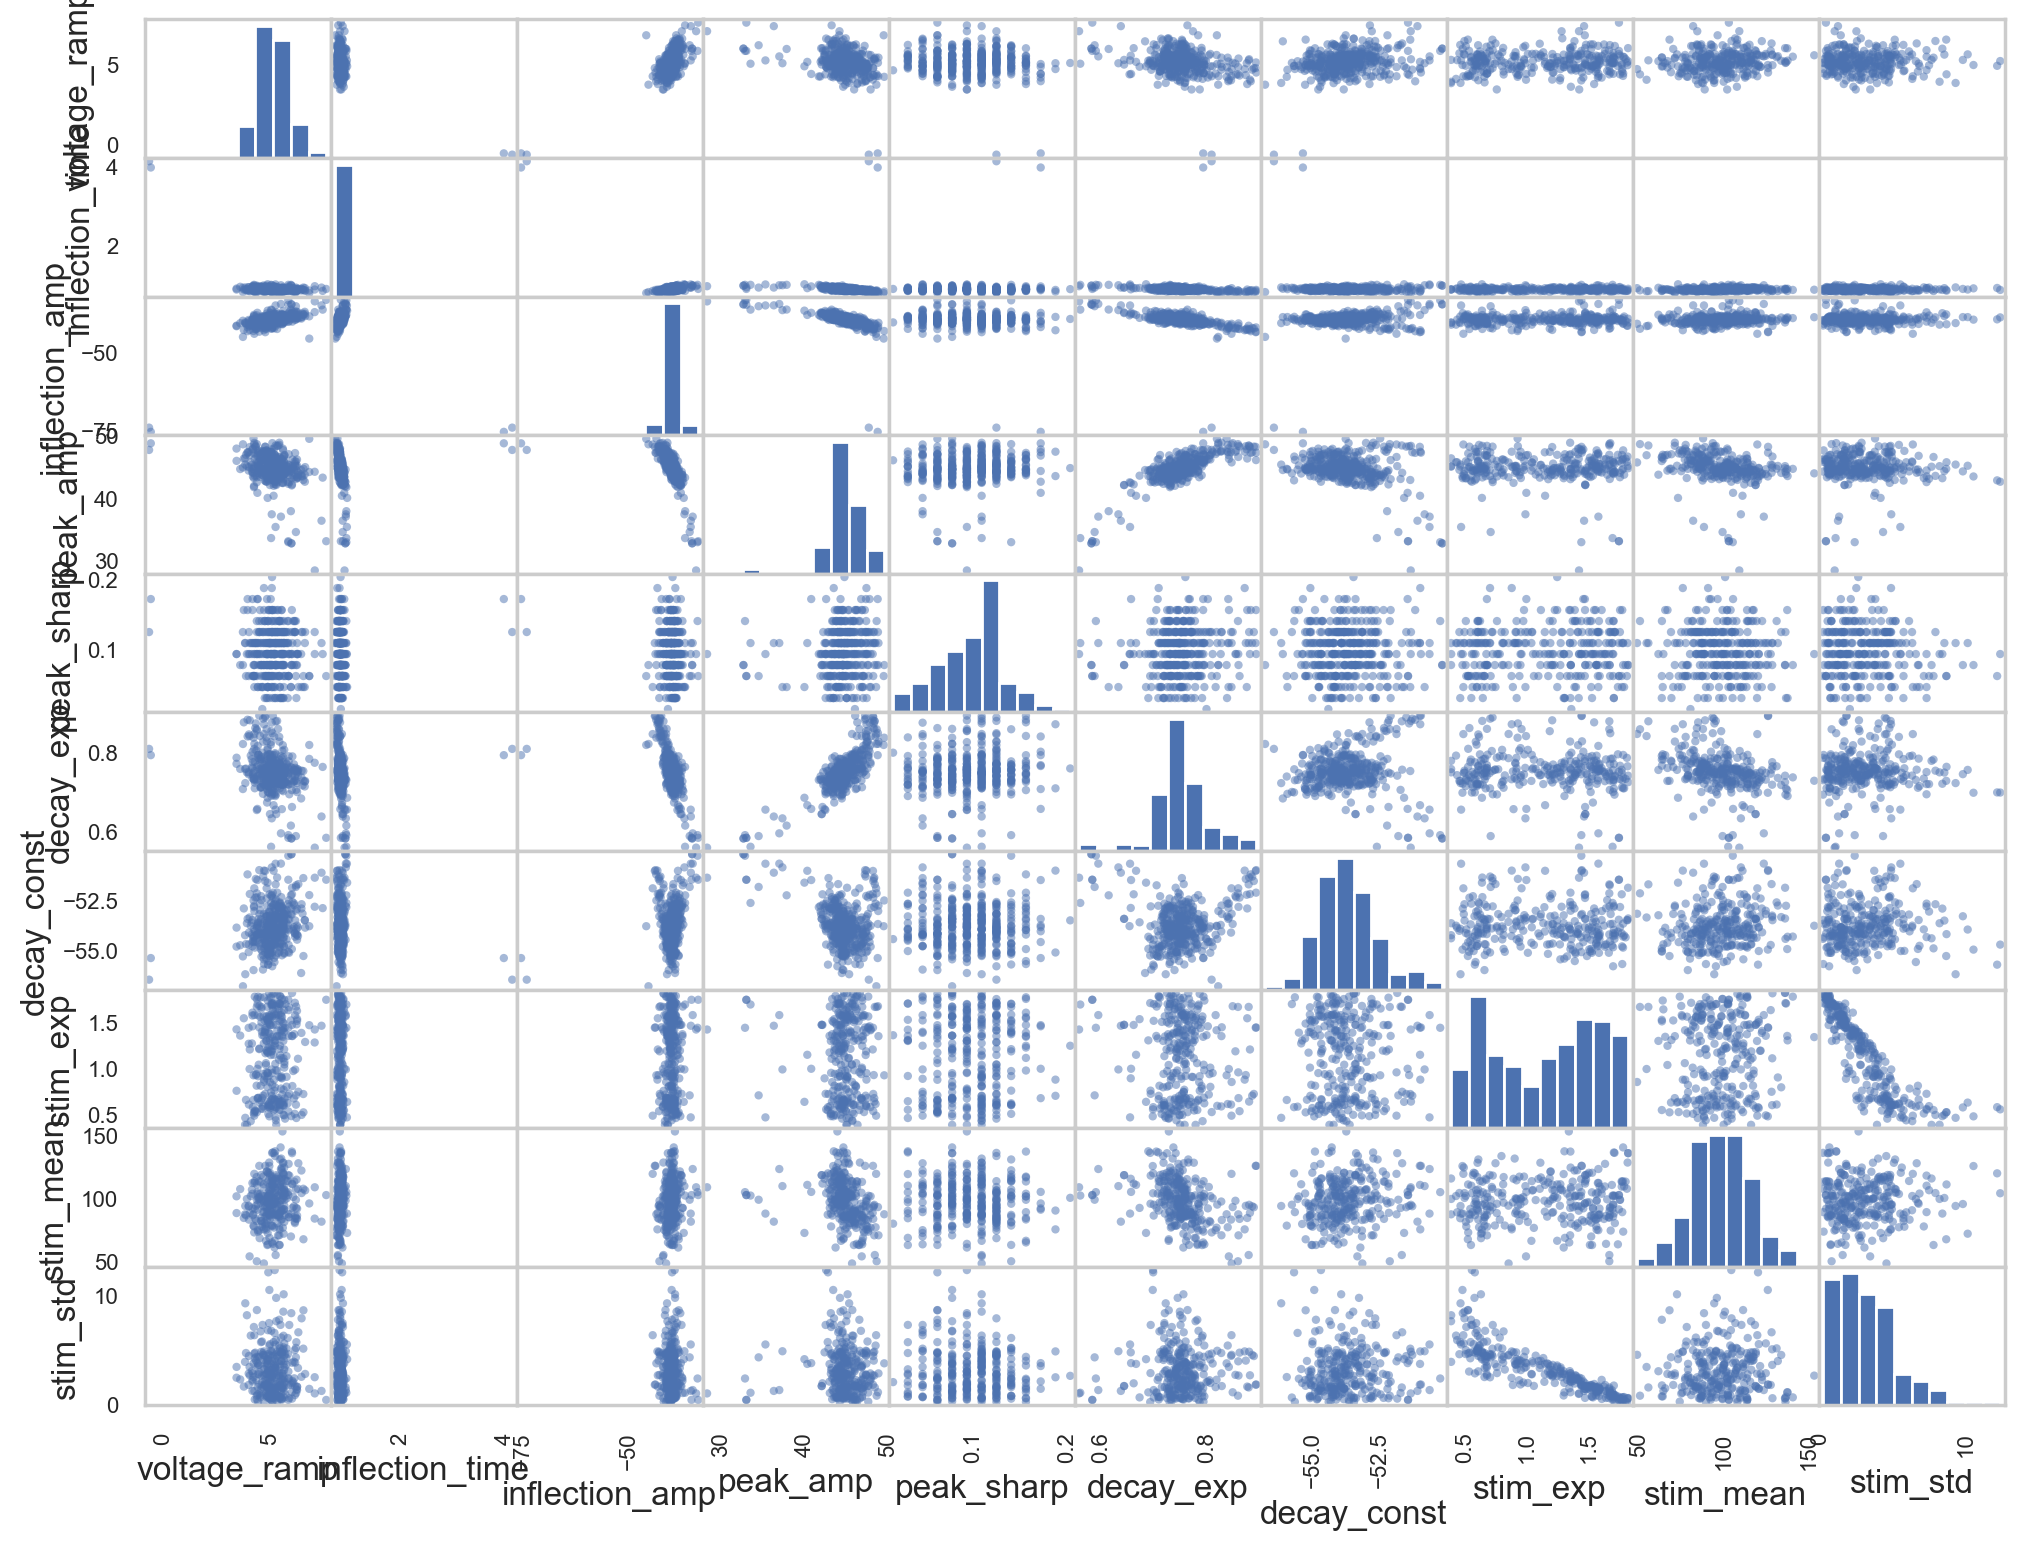

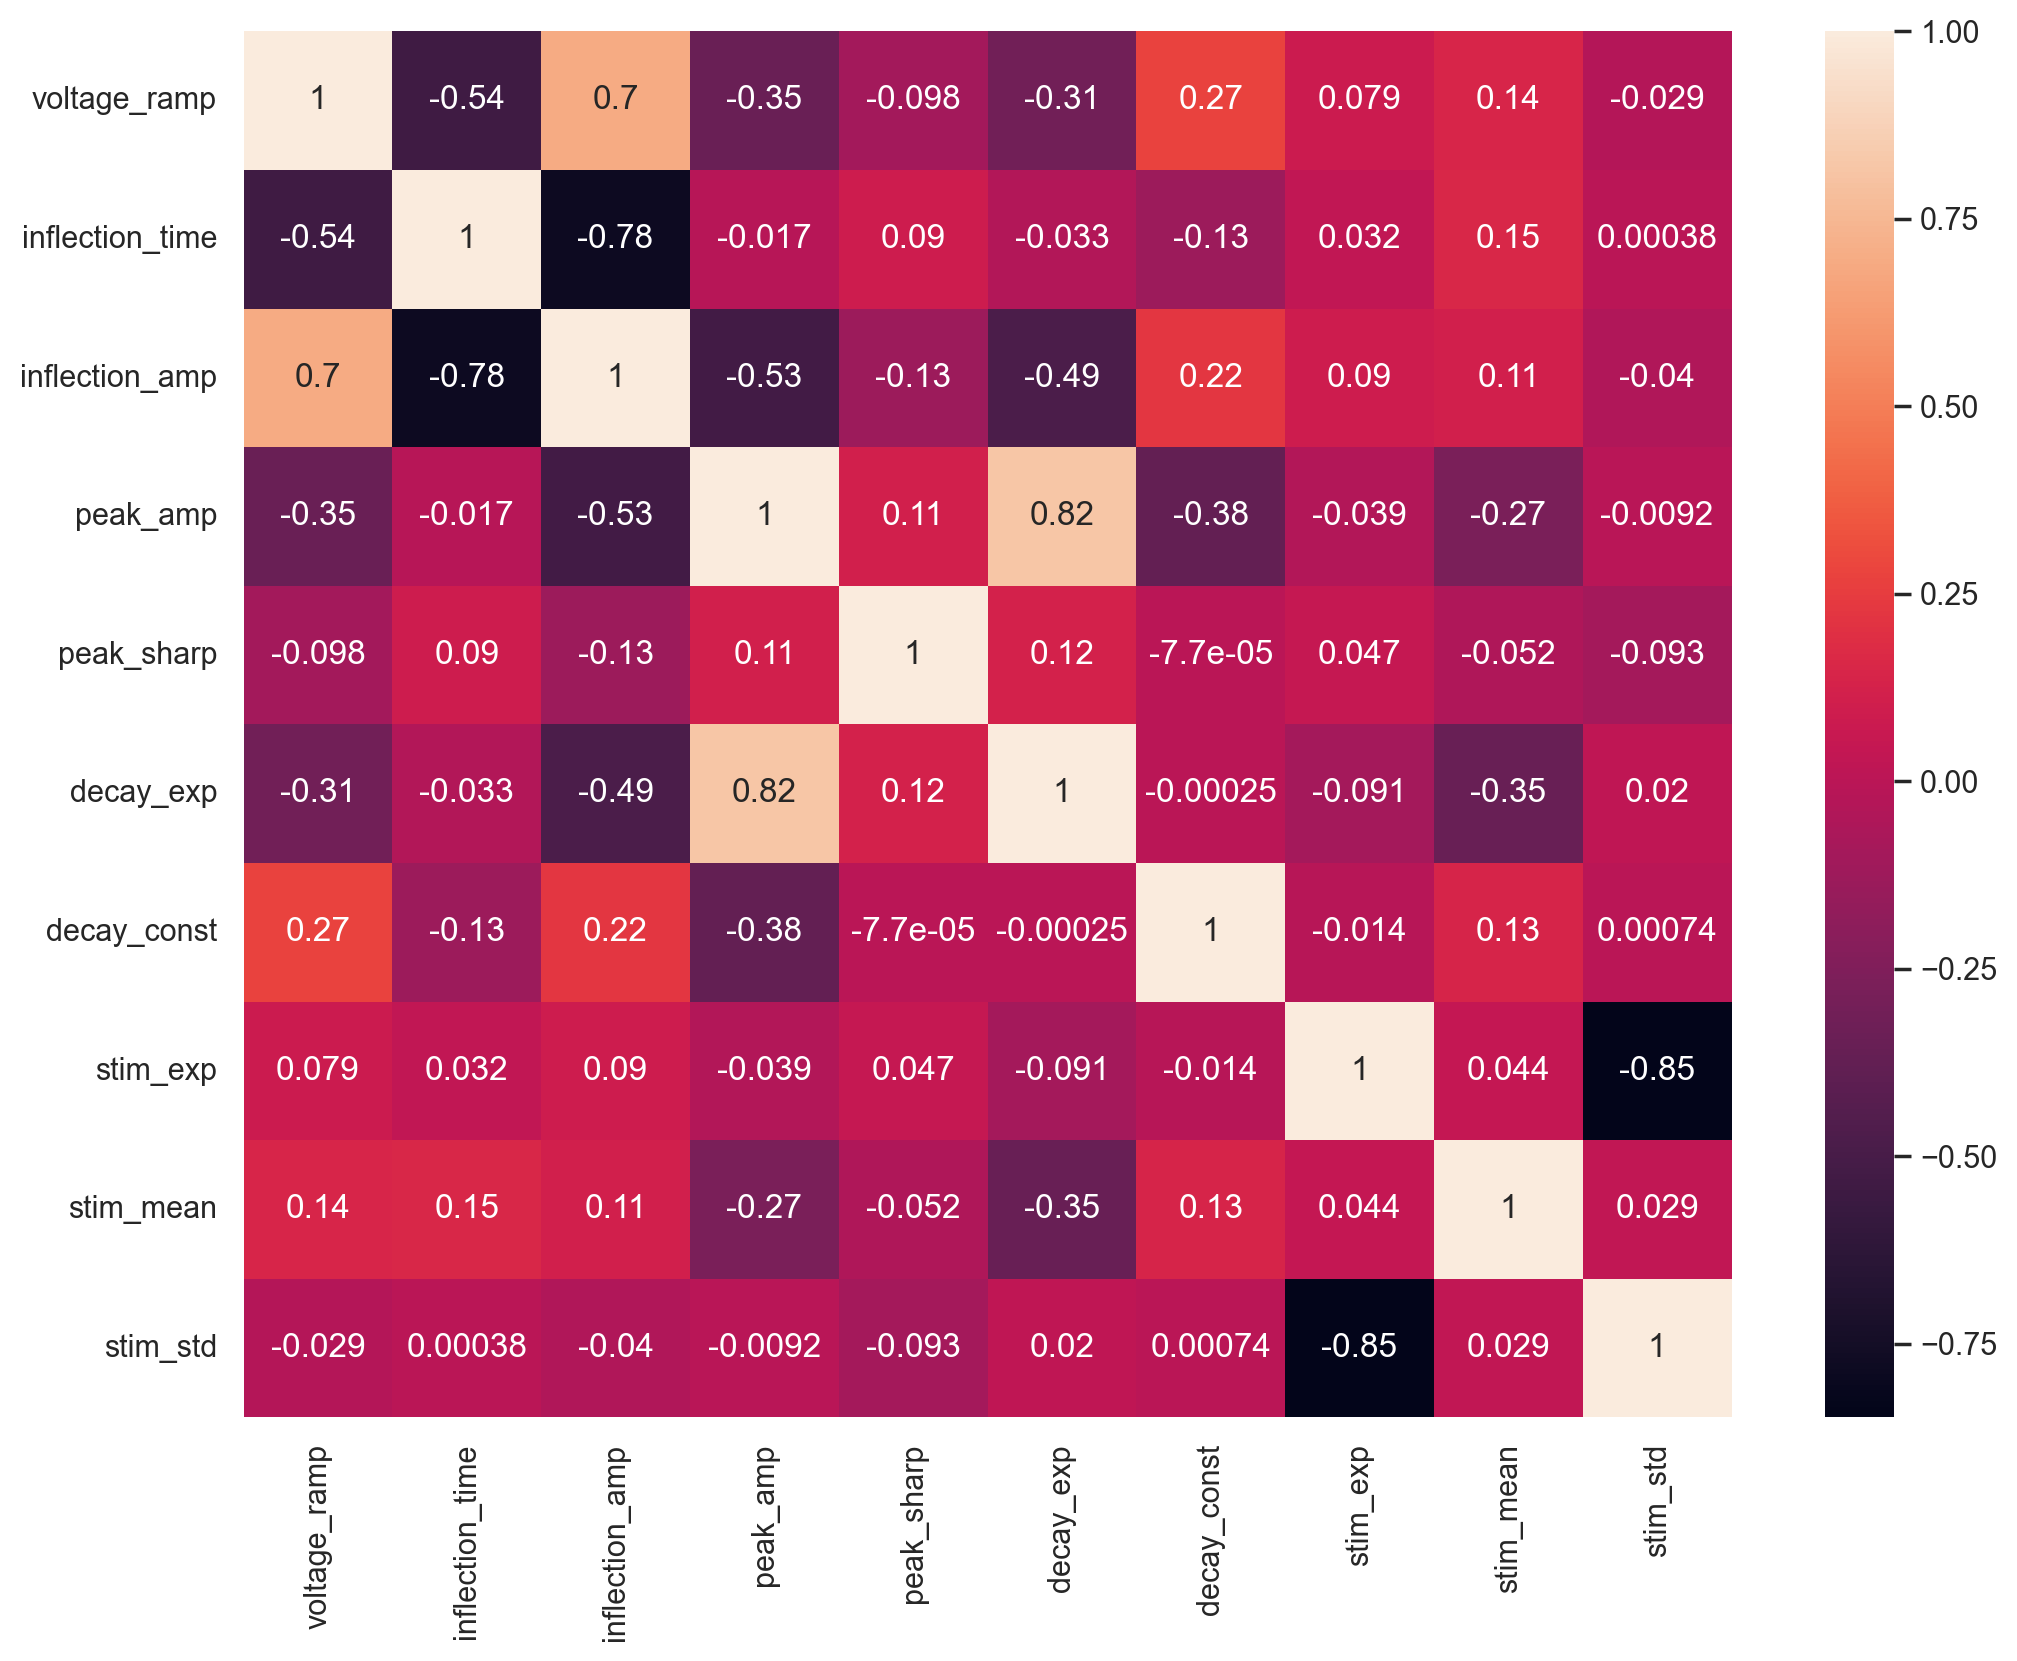

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_95964/1211550852.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  p = pval.applymap(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))


,voltage_ramp,inflection_time,inflection_amp,peak_amp,peak_sharp,decay_exp,decay_const,stim_exp,stim_mean,stim_std
voltage_ramp,1.0***,-0.54***,0.7***,-0.35***,-0.1,-0.31***,0.27***,0.08,0.14*,-0.03
inflection_time,-0.54***,1.0***,-0.78***,-0.02,0.09,-0.03,-0.13*,0.03,0.15**,0.0
inflection_amp,0.7***,-0.78***,1.0***,-0.53***,-0.13*,-0.49***,0.22***,0.09,0.11,-0.04
peak_amp,-0.35***,-0.02,-0.53***,1.0***,0.11*,0.82***,-0.38***,-0.04,-0.27***,-0.01
peak_sharp,-0.1,0.09,-0.13*,0.11*,1.0***,0.12*,-0.0,0.05,-0.05,-0.09
decay_exp,-0.31***,-0.03,-0.49***,0.82***,0.12*,1.0***,-0.0,-0.09,-0.35***,0.02
decay_const,0.27***,-0.13*,0.22***,-0.38***,-0.0,-0.0,1.0***,-0.01,0.13*,0.0
stim_exp,0.08,0.03,0.09,-0.04,0.05,-0.09,-0.01,1.0***,0.04,-0.85***
stim_mean,0.14*,0.15**,0.11,-0.27***,-0.05,-0.35***,0.13*,0.04,1.0***,0.03
stim_std,-0.03,0.0,-0.04,-0.01,-0.09,0.02,0.0,-0.85***,0.03,1.0***


In [34]:

df_all = df.drop(['sweep', 'stim_type', 'pink_type', 'spike_num'], axis=1)

pd.plotting.scatter_matrix(df_all, alpha=0.5)
plt.show()

spikes_corr = df_all.corr()
# plot the heatmap and annotation on it
sns.heatmap(spikes_corr, xticklabels=spikes_corr.columns, yticklabels=spikes_corr.columns, annot=True)
plt.show()

rho = df_all.corr()
pval = df_all.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.applymap(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

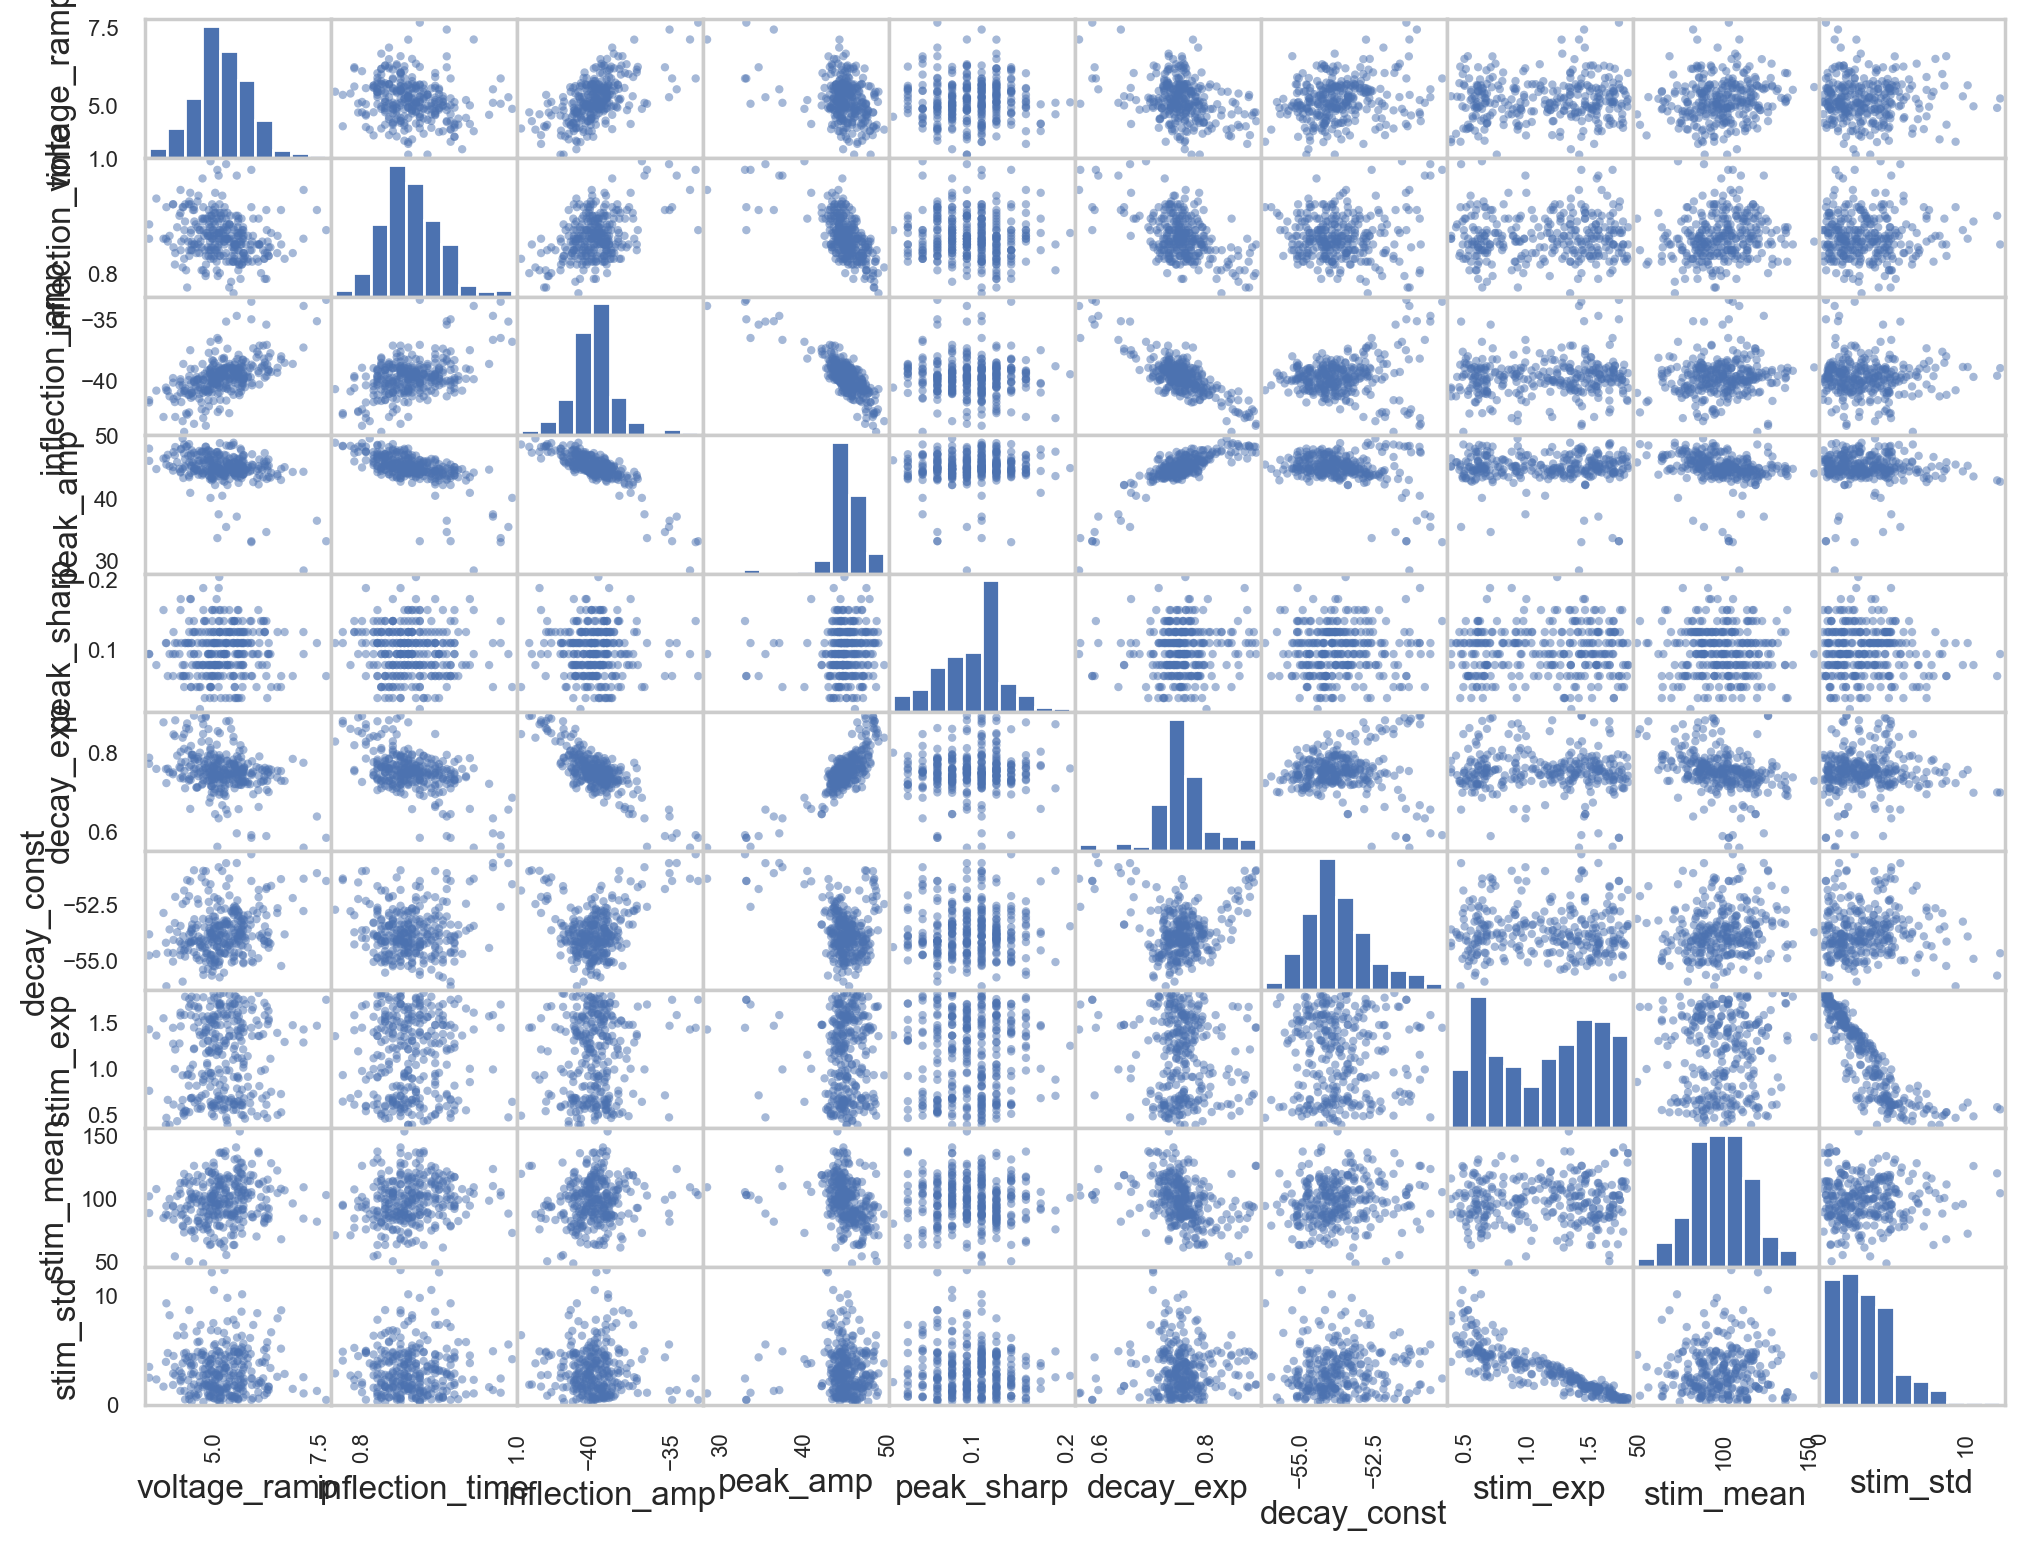

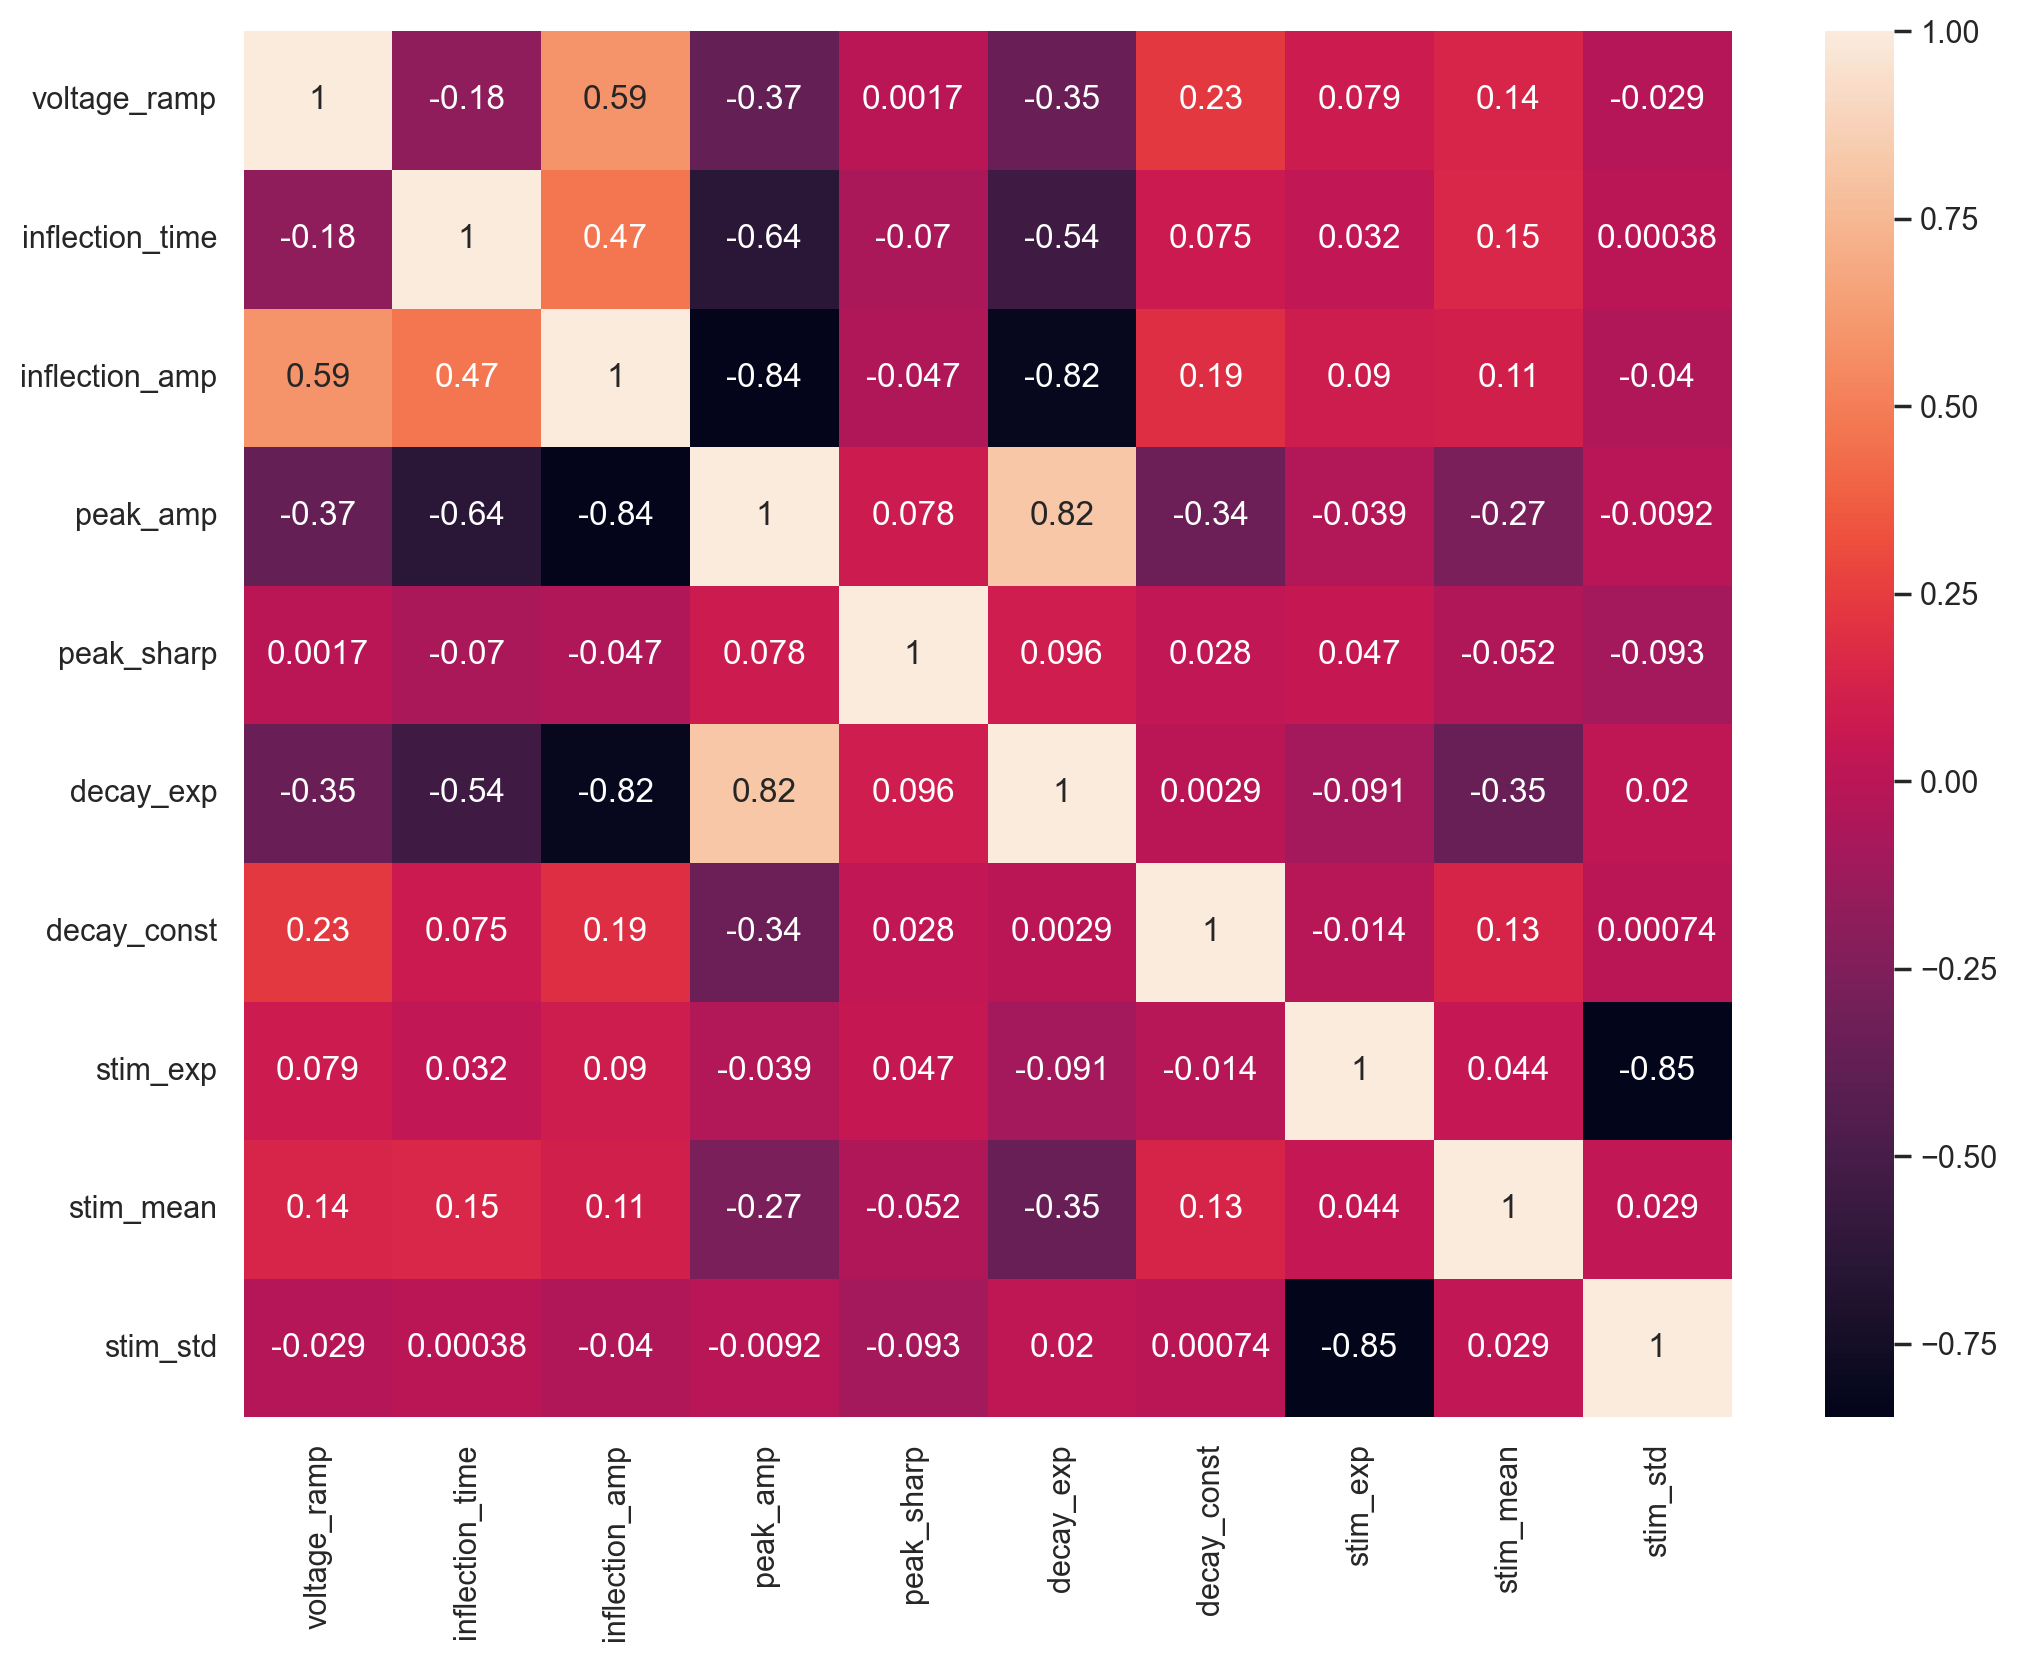

/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_95964/3065842352.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  p = pval.applymap(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))


,voltage_ramp,inflection_time,inflection_amp,peak_amp,peak_sharp,decay_exp,decay_const,stim_exp,stim_mean,stim_std
voltage_ramp,1.0***,-0.18**,0.59***,-0.37***,0.0,-0.35***,0.23***,0.08,0.14*,-0.03
inflection_time,-0.18**,1.0***,0.47***,-0.64***,-0.07,-0.54***,0.07,0.03,0.15**,0.0
inflection_amp,0.59***,0.47***,1.0***,-0.84***,-0.05,-0.82***,0.19**,0.09,0.11,-0.04
peak_amp,-0.37***,-0.64***,-0.84***,1.0***,0.08,0.82***,-0.34***,-0.04,-0.27***,-0.01
peak_sharp,0.0,-0.07,-0.05,0.08,1.0***,0.1,0.03,0.05,-0.05,-0.09
decay_exp,-0.35***,-0.54***,-0.82***,0.82***,0.1,1.0***,0.0,-0.09,-0.35***,0.02
decay_const,0.23***,0.07,0.19**,-0.34***,0.03,0.0,1.0***,-0.01,0.13*,0.0
stim_exp,0.08,0.03,0.09,-0.04,0.05,-0.09,-0.01,1.0***,0.04,-0.85***
stim_mean,0.14*,0.15**,0.11,-0.27***,-0.05,-0.35***,0.13*,0.04,1.0***,0.03
stim_std,-0.03,0.0,-0.04,-0.01,-0.09,0.02,0.0,-0.85***,0.03,1.0***


In [35]:
df_pink = df.loc[df['stim_type'] == 'pink']
df_pink = df_pink.drop(['sweep', 'stim_type', 'pink_type', 'spike_num'], axis=1)

pd.plotting.scatter_matrix(df_pink, alpha=0.5)
plt.show()

spikes_corr = df_pink.corr()
# plot the heatmap and annotation on it
sns.heatmap(spikes_corr, xticklabels=spikes_corr.columns, yticklabels=spikes_corr.columns, annot=True)
plt.show()

rho = df_pink.corr()
pval = df_pink.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(*rho.shape)
p = pval.applymap(lambda x: ''.join(['*' for t in [0.001,0.01,0.05] if x<=t]))
rho.round(2).astype(str) + p

In [36]:
# Calculate the number of spikes in each sweep
spike_counts = df.groupby('sweep')['spike_num'].count()

# Calculate the duration of each sweep in seconds using the indices from spike_counts
sweep_durations = {sweep: len(all_data[sweep]) / fs for sweep in spike_counts.index}

# Calculate the firing rate for each sweep
firing_rates = {sweep: spike_counts[sweep] / sweep_durations[sweep] for sweep in spike_counts.index}

# Convert the dictionary to a DataFrame for easier handling and visualization
firing_rate_df = pd.DataFrame(list(firing_rates.items()), columns=['Sweep', 'Firing Rate'])

stim_type_series = df.loc[spike_counts.index, 'stim_type']
# Add the 'stim_type' to the firing_rate_df
firing_rate_df['Stim Type'] = firing_rate_df['Sweep'].map(stim_type_series)

# Display the updated DataFrame
print(firing_rate_df)

    Sweep  Firing Rate Stim Type
0       2     0.284900  constant
1       7     0.330797  constant
2      11     0.330797  constant
3      16     2.487559      pink
4      17     0.248756      pink
5      19     0.498338      pink
6      20     0.664451      pink
7      21     0.498338      pink
8      22     0.166113      pink
9      23     1.993354      pink
10     24     1.661128      pink
11     25     1.827241  constant
12     26     1.162790      pink
13     27     3.488369      pink
14     28     2.990031      pink
15     29     2.657805      pink
16     30     2.823918      pink
17     36     0.330797      pink
18     38     0.248756      pink
19     39     0.664451      pink
20     40     0.664451      pink
21     41     0.498338      pink
22     42     0.166113      pink
23     43     1.993354      pink
24     44     1.661128      pink
25     45     1.827241      pink
26     46     0.996677      pink
27     47     3.488369      pink
28     48     3.156144      pink
29     49 

### Logistic regression to predict stim type from spike features

In [37]:
# Define features (X) and target variable (y)
X = df.drop(columns=['stim_type', 'spike_num', 'sweep', 'stim_exp','stim_mean','stim_std', 'pink_type'])
y = df['stim_type']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define preprocessing steps
numeric_features = X.select_dtypes(include=['float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Define logistic regression model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(multi_class='multinomial', solver='lbfgs'))
])

# Train the model
model.fit(X_train, y_train)

# Evaluate the model
accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8421052631578947


#### Visualize results of logistic regression

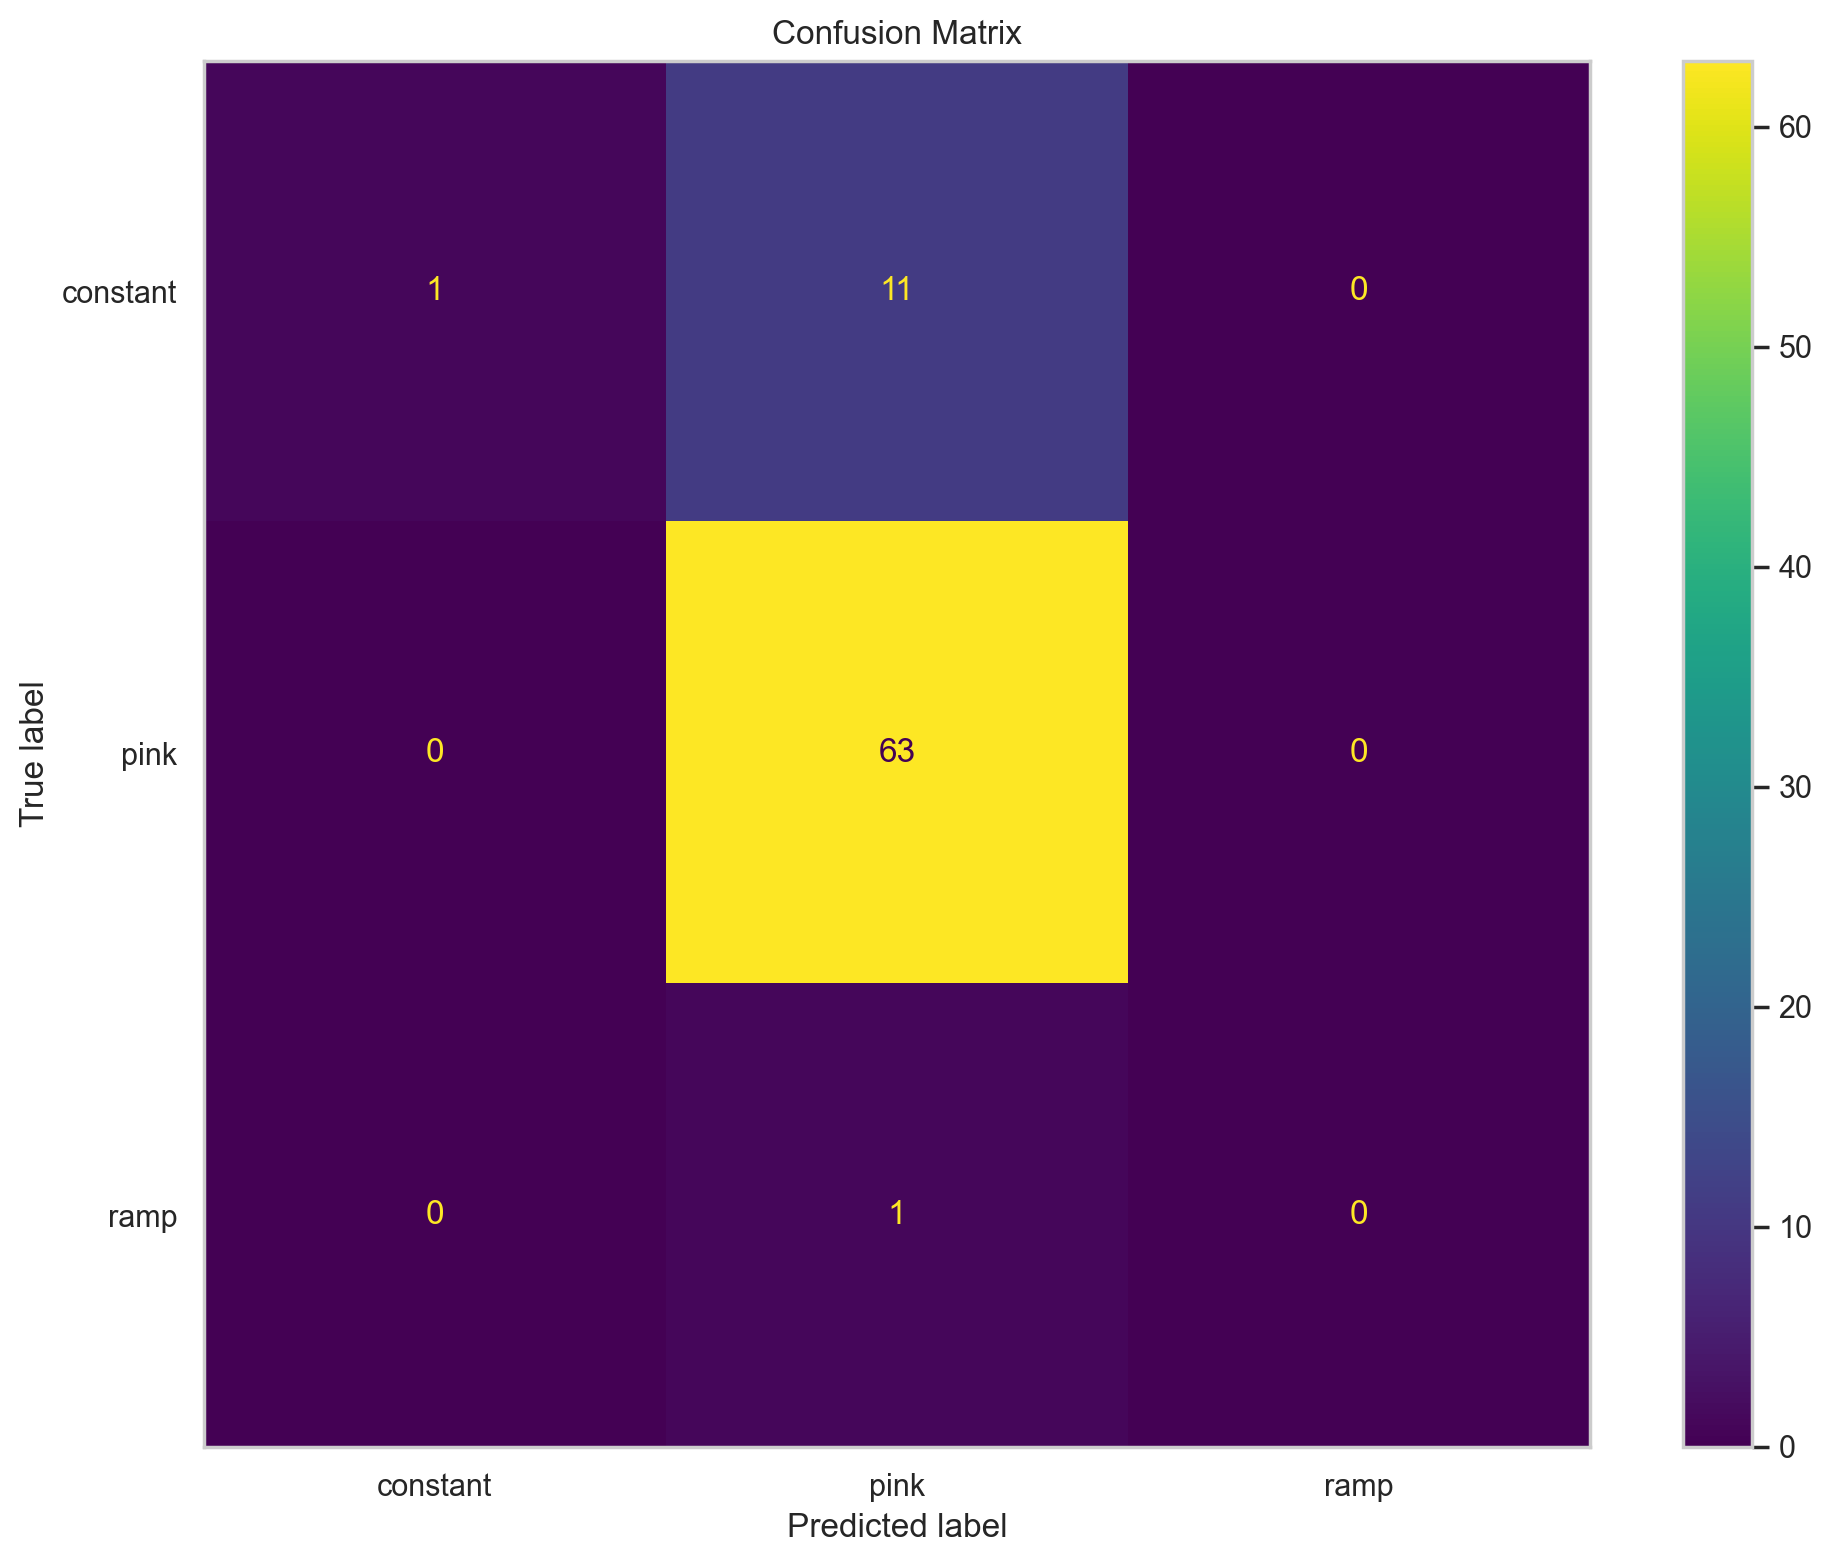

In [38]:
# Plot confusion matrix
conf_matrix = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

plt.title('Confusion Matrix')
plt.show()

#### See feature importance

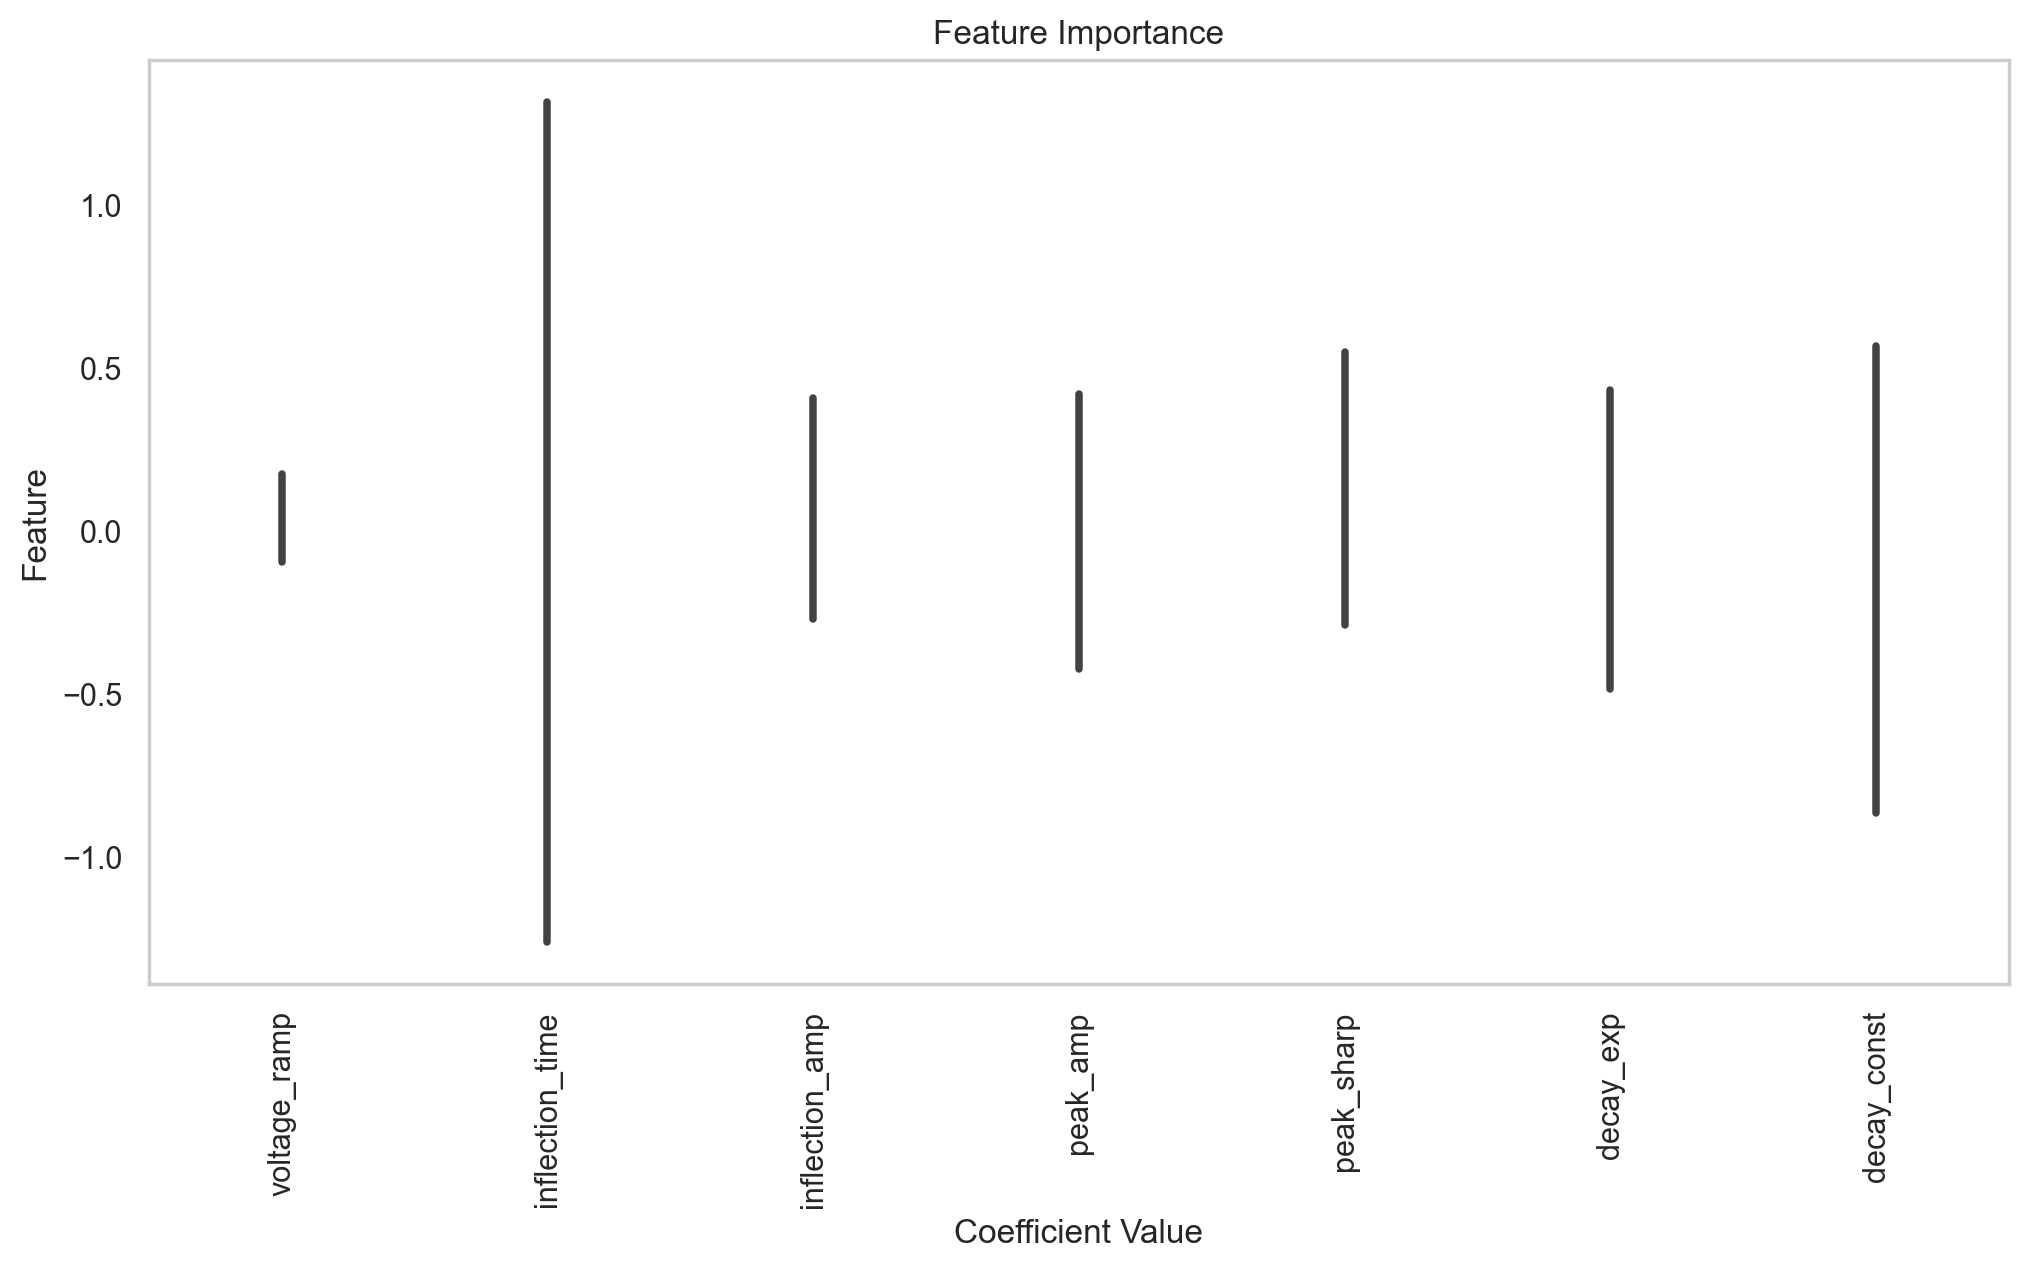

In [39]:
#Fit the OneHotEncoder on the categorical features
onehot_encoder = model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
onehot_encoder.fit(X_train[categorical_features])

# Get the categories from the OneHotEncoder
encoded_column_names = onehot_encoder.get_feature_names_out(input_features=categorical_features)

# Combine the encoded column names with the remaining column names
feature_names = list(encoded_column_names) + list(numeric_features)

# Get coefficients from the logistic regression model
coefficients = model.named_steps['classifier'].coef_

# Create DataFrame for coefficients and feature names
coef_df = pd.DataFrame(data=coefficients, columns=feature_names)

# Plot coefficients
plt.figure(figsize=(12, 6))
sns.barplot(data=coef_df)
plt.title('Feature Importance')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.xticks(rotation=90)
plt.show()

#### SVM

In [40]:

# Define pipeline with SVM classifier
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(kernel='linear', probability=True))  # Linear kernel for simplicity
])

# Define hyperparameters for grid search
param_grid = {
    'classifier__C': [0.1, 1, 10, 100]  # Regularization parameter
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best model and its accuracy
best_model = grid_search.best_estimator_
accuracy = best_model.score(X_test, y_test)
print(f"Best Model Accuracy (SVM): {accuracy}")

/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best Model Accuracy (SVM): 0.8421052631578947


#### Random forest

In [41]:
# Define pipeline with Random Forest classifier
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=48))  # 100 decision trees
])

# Define hyperparameters for grid search
param_grid = {
    'classifier__max_depth': [None, 10, 20],  # Maximum depth of the tree
    'classifier__min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'classifier__min_samples_leaf': [1, 2, 4],  # Minimum number of samples required to be at a leaf node
    'classifier__bootstrap': [True, False]  # Whether bootstrap samples are used when building trees
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get the best model and its accuracy
best_model = grid_search.best_estimator_
accuracy = best_model.score(X_test, y_test)
print(f"Best Model Accuracy (Random Forest): {accuracy}")



/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best Model Accuracy (Random Forest): 0.881578947368421


#### Get average accuracy for random forest with multiple random states 

In [ ]:

# Define a range of random states
random_states = [42, 48, 64, 128, 256]

# List to store results
accuracies = []

for state in random_states:
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=state))
    ])
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    accuracies.append(best_model.score(X_test, y_test))



/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_split.py:700: UserWarning: The least populated class in y has

In [ ]:
# Calculate average accuracy
average_accuracy = np.mean(accuracies)
print(f"Average Model Accuracy (Random Forest): {average_accuracy:.3f}")

average_std = np.std(accuracies)
print(f"standard deviation models (Random Forest): {average_std:.3f}")



In [ ]:
accuracies

In [ ]:
plt.plot(

In [ ]:
# Visualize feature importance
importances = best_model.named_steps['classifier'].feature_importances_

# Fit OneHotEncoder on the categorical features using training data
best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].fit(X_train[categorical_features])

# Get feature names for categorical features after one-hot encoding
feature_names_cat = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)

# Combine encoded column names with numeric feature names
feature_names = list(feature_names_cat) + list(numeric_features)
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)

# Define color mapping
color_mapping = {
    'peak_amp': 'C5', # Example colors
    'decay_const': 'C6',
    'decay_exp': 'C6',
    'inflection_amp': 'C3',
    'voltage_ramp': 'C4',
    'inflection_time': 'C3',
    'peak_sharp': 'C5'
}

# Apply color mapping
feature_importance_df['Color'] = feature_importance_df['Feature'].map(color_mapping)


# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette=feature_importance_df['Color'])
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance', fontsize=20)
plt.ylabel('Feature', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

In [ ]:
# Generate confusion matrix
conf_matrix = ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
ax = plt.gca()
conf_matrix.plot(cmap='Blues', ax=ax, xticks_rotation=45, values_format='d')  # Plot the confusion matrix

# Adjust font size for annotations (numbers within the matrix)
for text in ax.texts:
    text.set_fontsize(14)  # Set the font size for annotations



plt.title('Confusion Matrix', fontsize=16)  # Increase the font size for title
plt.xlabel('Predicted Label', fontsize=17)  # Increase the font size for x-axis label
plt.ylabel('True Label', fontsize=17)       # Increase the font size for y-axis label
plt.xticks(fontsize=16)  # Increase the font size for x-axis ticks
plt.yticks(fontsize=16)  # Increase the font size for y-axis ticks

plt.show()